# IQM QEC Pipeline Showcase

This notebook shows the main functionality we implemented for running and analysing surface-code QEC on the IQM Emerald architecture.

## What we implemented

### Standard IQM surface-code pipeline

We built a fully automated pipeline for rotated surface-code memory experiments.

The user can choose the distance, number of rounds, shots, basis, decoder model, and whether to run on hardware or in simulation.

The pipeline does the full chain:

Stim circuit  
→ Qiskit circuit  
→ IQM Emerald hardware or synthetic sampling  
→ syndrome extraction  
→ MWPM decoding  
→ logical error probability / logical error rate extraction

Main features:

- Stim generates the surface-code circuit, detector structure, and logical observable.
- Qiskit translates the circuit into hardware-executable operations.
- The circuit is mapped onto IQM Emerald using calibration-aware layout optimization.
- The layout optimizer uses qubit quality and coupler quality, aiming for high-quality zero-SWAP placements.
- Raw measurement bitstrings are converted back into Stim detector events.
- PyMatching performs offline MWPM decoding.
- Logical error rate is extracted by running several round counts and fitting logical error probability vs rounds.

The pipeline has two modes:

- `hardware`: run directly on IQM Emerald through Resonance.
- `synthetic`: sample from an Emerald-calibrated noise model, which lets us test larger lattices.

Decoder options:

- `exact`: detector error model using calibration data for specific qubits/couplers.
- `average`: detector error model using averaged calibration-derived noise parameters.

### Snakes-and-Ladders defective-lattice pipeline

We also implemented a Snakes-and-Ladders pipeline for defective lattices.

This extends the standard IQM pipeline to cases where parts of the lattice are unavailable or intentionally removed.

Supported defects:

- data-qubit defects
- ancilla-qubit defects
- coupler defects

The SnL pipeline:

- deforms stabilizers around defects
- builds the corresponding deformed surface-code circuit
- visualizes the superstabilizer measurement rounds
- supports both hardware-compatible patches and larger synthetic simulations

We use this to compare:

- clean surface-code patches
- defective normal surface-code patches
- SnL-deformed defective patches

### Visualization tools

We added visualization helpers to make the pipeline easier to sanity-check.

These include:

- IQM Emerald lattice placement plots
- used-qubit and defective-coupler highlighting
- gate/reset/measurement timeslice plots on the Emerald layout
- SnL superstabilizer plaquette plots
- logical error probability and logical error rate plots

### Pulse-level optimization showcase

This is a standalone control-layer example. It is not integrated into the final QEC hardware pipeline yet.

The pulse-level optimization demonstrates:

- net-zero CZ pulses cancel the flux-area drift proxy
- CLEAR pulses reduce the readout residual photon proxy
- unconditional active reset reduces reset latency

This shows how pulse-level improvements could feed into a more hardware-aware QEC stack.

## Notebook examples

This notebook contains the following examples:

1. Clean `d=3` hardware run  
   Shows that the standard IQM pipeline works on Emerald.

2. Average vs exact detector error model comparison  
   Compares calibration-aware decoder choices on hardware.

3. Synthetic scaling on larger lattices  
   Uses the Emerald-derived noise model to simulate larger-distance surface codes.

4. Snakes-and-Ladders defective-lattice simulations  
   Shows how the SnL deformation handles defective qubits and couplers.

5. Pulse-level optimization
   Shows a pulse-control example for CZ, readout, and reset optimization.

In [133]:
import importlib
import os
import subprocess
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

SNL_REPO_URL = "https://github.com/amazon-science/snakes_and_ladders_adapting_the_surface_code_to_defects.git"
SNL_REPO_DIR = Path("snakes_and_ladders_adapting_the_surface_code_to_defects")
if not (SNL_REPO_DIR / "defects_module").exists():
    print("Downloading Snakes-and-Ladders dependency...")
    subprocess.run(["git", "clone", "--depth", "1", SNL_REPO_URL, str(SNL_REPO_DIR)], check=True)
os.environ.setdefault("SNL_REPO", str(SNL_REPO_DIR.resolve()))
if str(SNL_REPO_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(SNL_REPO_DIR.resolve()))

import iqm_qec_pipeline as iqm
import snl_iqm_pipeline as snl
import helper_visualisation as hv

from snakes_and_ladders_adapting_the_surface_code_to_defects.defects_module.base import PauliT, Pos, SuperStabilizer  # noqa: E402
from snakes_and_ladders_adapting_the_surface_code_to_defects.defects_module.code_library import RotatedSurfaceCode  # noqa: E402
from snakes_and_ladders_adapting_the_surface_code_to_defects.defects_module.defects import DefectiveSurfaceCode, Heuristics  # noqa: E402
from snakes_and_ladders_adapting_the_surface_code_to_defects.defects_module.utils import memory_program, standard_noise  # noqa: E402

iqm = importlib.reload(iqm)
snl = importlib.reload(snl)
hv = importlib.reload(hv)

# Global run controls. Use hardware only when you are ready to submit real jobs.
RUN_MODE = "synthetic"      # "synthetic" or "hardware"
API_URL = "https://resonance.iqm.tech/"
TOKEN = "QAgmAe1q34cPweXxUtCu3RuMUIAVZrUhiPfqDCyChu0BnqZwjTJ2wpu6esoxHuYM"    # set your IQM token here
SHOTS = 5_000
ROUND_VALUES = (1, 3, 5, 10)
BASIS = "Z"
DECODER_NOISE = "average"     # "exact" or "average"

CAL = iqm.refresh_calibration_if_needed(
    api_url=API_URL,
    token=TOKEN,
    quantum_computer="emerald",
)
print("Using calibration:", CAL)

Loaded today's calibration data: calibration_data/2026-06-08T06_12_52.097243Z.json
Using calibration: calibration_data/2026-06-08T06_12_52.097243Z.json


## 1. Clean `d=3` hardware run

First let us do a basic run of d=3 surface code using the `iqm_qec_pipeline`. It optimizes the d=3 layout on the IQM Emerald lattice, runs the round sweep, plots the fitted logical error rate, and visualizes the stabilizer-measurement couplings. 

The swap count is included as part of the data. We get swap_count from the transpiled Qiskit circuit, after mapping the Stim/Qiskit circuit onto the IQM backend. Since we optimized the lattice, we get `'swap_count': 0`, which you can check in the `clean_d3["summary"]`.  

rounds=1 | corrected_prob=0.1654 | uncorrected_prob=0.2342 | swap_count=0 | skipped_ops=0 | job=019ea7f4-8743-7111-bdd8-696f2ba22571
rounds=3 | corrected_prob=0.4476 | uncorrected_prob=0.4506 | swap_count=0 | skipped_ops=0 | job=019ea7f4-a235-7a80-93e4-ae0af35b7796
rounds=5 | corrected_prob=0.4858 | uncorrected_prob=0.4892 | swap_count=0 | skipped_ops=0 | job=019ea7f4-bf94-7d10-8c47-1e5b7437bda7
rounds=8 | corrected_prob=0.495 | uncorrected_prob=0.492 | swap_count=0 | skipped_ops=0 | job=019ea7f4-dede-79f0-83fb-e0d5986ec6fc
rounds=10 | corrected_prob=0.502 | uncorrected_prob=0.5014 | swap_count=0 | skipped_ops=0 | job=019ea7f4-fe1f-7000-bba5-56932a345f04
rounds=15 | corrected_prob=0.4942 | uncorrected_prob=0.5048 | swap_count=0 | skipped_ops=0 | job=019ea7f5-2396-7e93-ac48-d6dd695501cf
rounds=20 | corrected_prob=0.505 | uncorrected_prob=0.5024 | swap_count=0 | skipped_ops=0 | job=019ea7f5-4bf6-73f1-8fe1-961c9c0552a1


{'distance': 3,
 'round_values': [1, 3, 5, 8, 10, 15, 20],
 'shots': 5000,
 'run_mode': 'hardware',
 'decoder_noise': 'average',
 'logical_error_rate': 0.20369561108805545,
 'uncorrected_logical_error_rate': 0.2450132350411752,
 'mapping': {1: 16,
  2: 8,
  3: 9,
  5: 4,
  8: 25,
  9: 17,
  10: 18,
  11: 10,
  12: 11,
  13: 5,
  14: 33,
  15: 34,
  16: 26,
  17: 27,
  18: 19,
  19: 20,
  25: 28},
 'layout_diagnostics': {'mapping_source': 'geometry',
  'score': -0.5004080959993421,
  'usable_twoq_gate_count': 24,
  'missing_twoq_gate_count': 0,
  'min_used_cz_fidelity': 0.9774628909076772,
  'candidate_count': 93,
  'exact_graph_error': None},
 'synthetic_defect_qubits': [],
 'synthetic_defect_couplers': [],
 'synthetic_defect_probability': None,
 'unavailable_iqm_couplers': [],
 'swap_count': 0,
 'skipped_hardware_operation_count': 0}

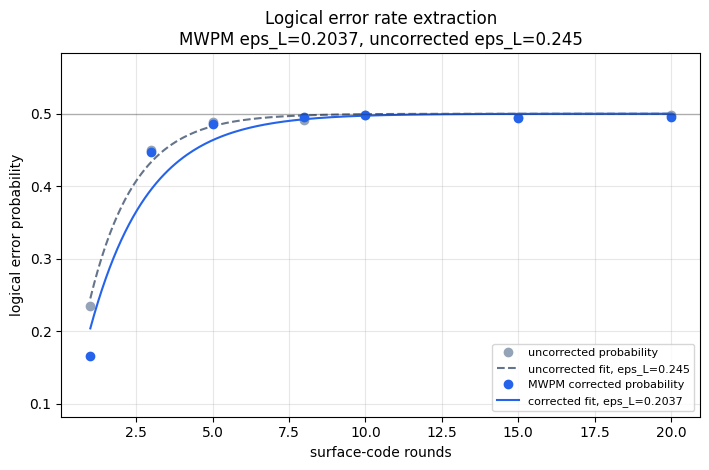

In [134]:
ROUND_VALUES = (1, 3, 5, 8, 10, 15, 20)
clean_d3 = iqm.run_round_sweep(
    distance=3,
    round_values=ROUND_VALUES,
    shots=SHOTS,
    run_mode="hardware",
    decoder_noise="average",
    cal=CAL,
    token=TOKEN,
    api_url=API_URL,
    optimize_layout=True,
    refresh_calibration=False,
    show_error_plot=True,
)

clean_d3["summary"] # as part of the summary you can see that number of swap counts is 0.


Here you can see the location on the lattice our layout optimizer found. The optimizer grades each subsection of the lattice by the score: 

$$
\text{score}
=
\sum_{q \in Q_{\text{used}}}
\left(
\log(F^{(1)}_q)
+
\log(1 - M_q)
\right)
+
\sum_{e \in E_{\text{used}}}
n_e \log(F^{(\mathrm{CZ})}_e)
$$


logarithmic scale is used to penalize very bad couplers and qubit comparatively more. 

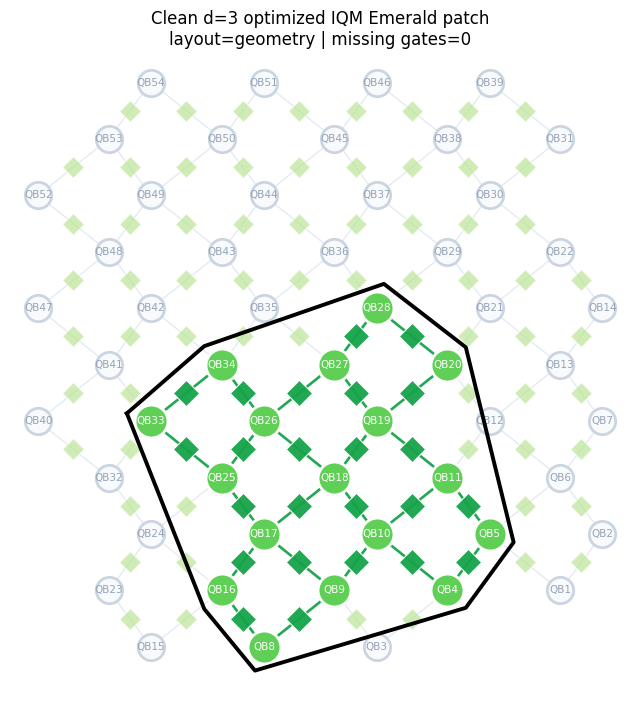

In [135]:
clean_d3_patch_fig = hv.plot_used_emerald_patch(
    clean_d3["results"][0],
    title="Clean d=3 optimized IQM Emerald patch",
)

Below, you can see the sequence of gates applied on hardware. It is comparable to the stim `circuit.diagram('timeslice-svg')` visualisation, but for IQM emerald.

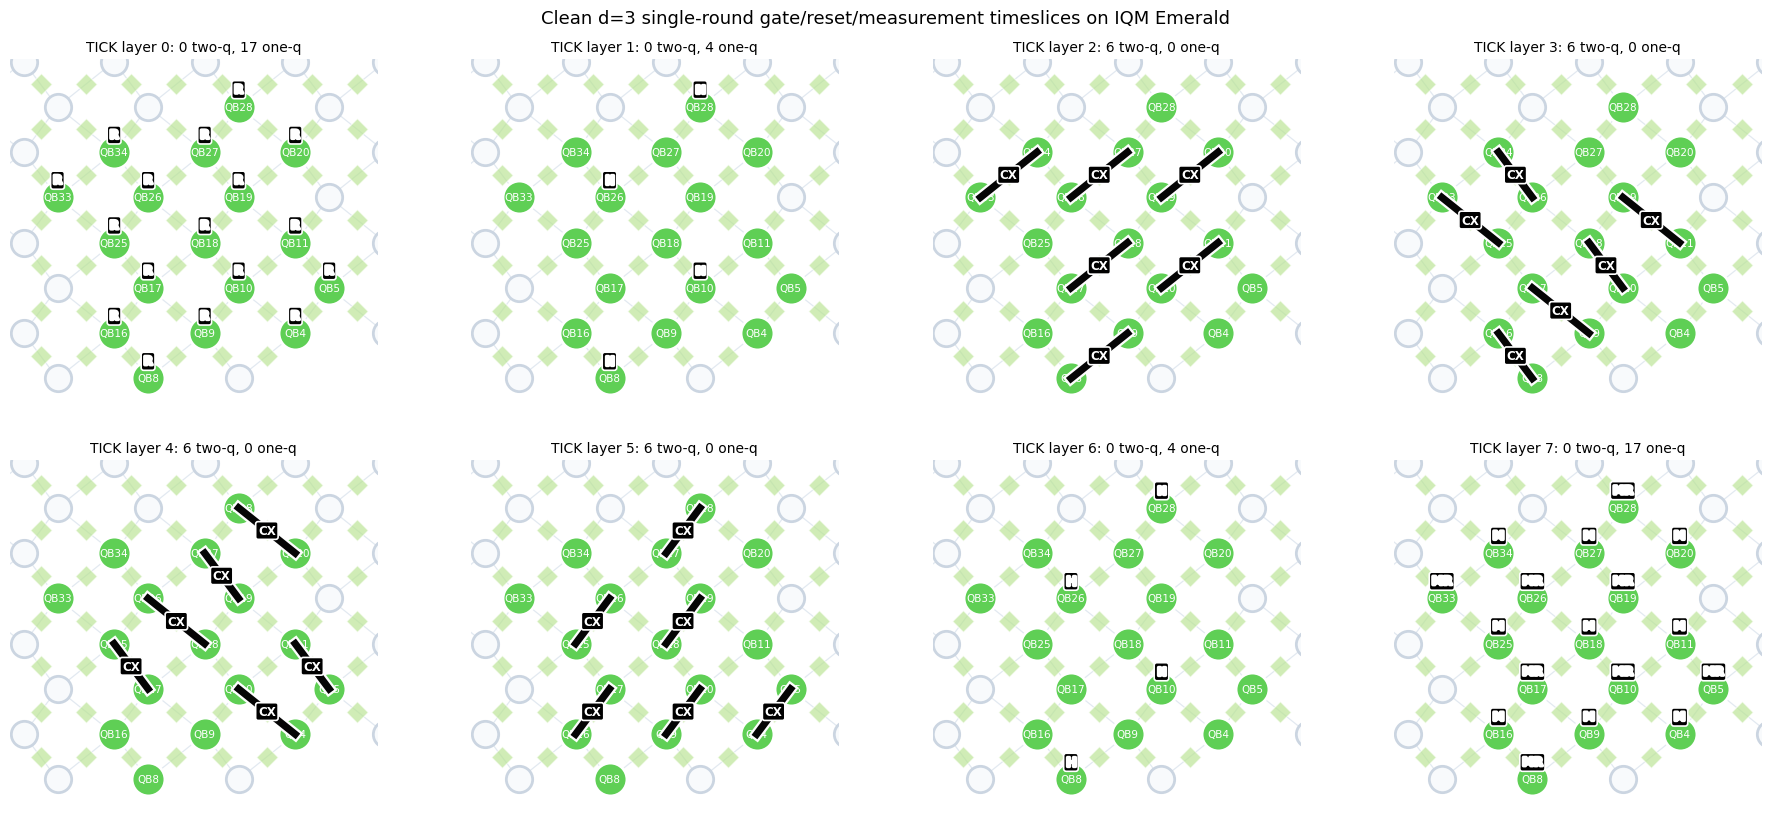

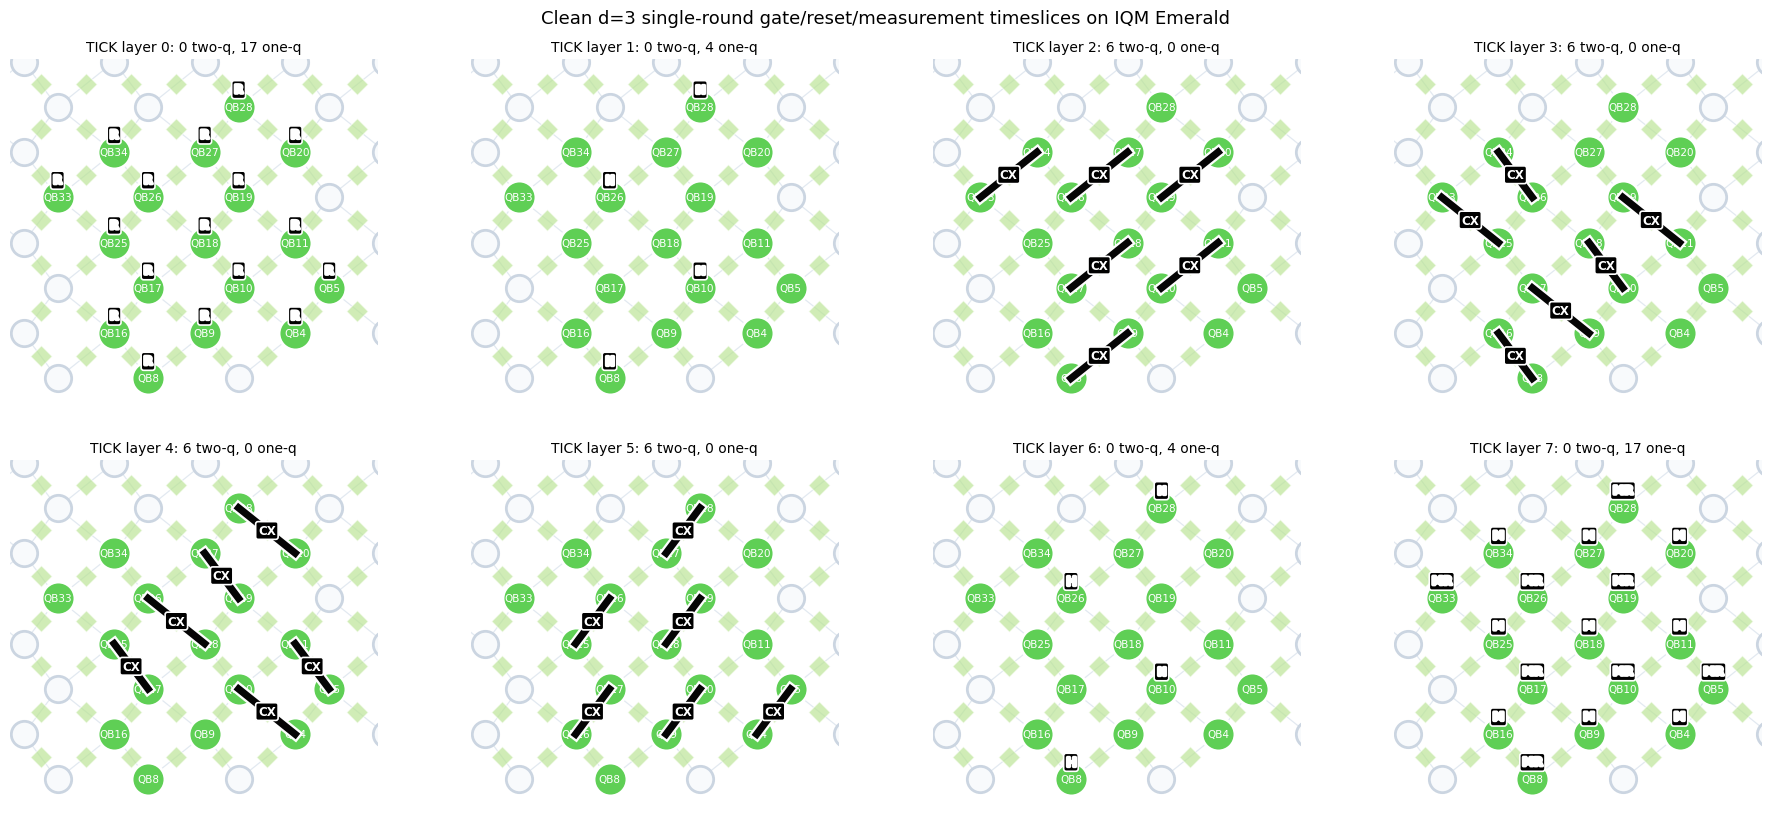

In [136]:
clean_d3_timeslice_fig = hv.plot_iqm_timeslice_layers(
    clean_d3["results"][0],
    max_layers=8,
    cols=4,
    title="Clean d=3 single-round gate/reset/measurement timeslices on IQM Emerald",
    zoom_to_used=True,
)
clean_d3_timeslice_fig


# 2. Average vs exact detector error model comparison 

We have the option to decode with two different detector error models; `exact` and `average`. `Exact` uses exact noise model for each qubit/coupler that was computed based on calibration data, and `average` uses the average noise from qubits and couplers. Let us compare their performance by decoding on the same hardware data. 

rounds=1 | corrected_prob=0.1582 | uncorrected_prob=0.243 | swap_count=0 | skipped_ops=0 | job=019ea7f5-a890-7a43-861f-29885cf3d1aa
rounds=3 | corrected_prob=0.4416 | uncorrected_prob=0.444 | swap_count=0 | skipped_ops=0 | job=019ea7f5-c20e-7920-98f6-80f25047ab4a
rounds=5 | corrected_prob=0.4874 | uncorrected_prob=0.4894 | swap_count=0 | skipped_ops=0 | job=019ea7f5-e13e-7c51-99f8-761d14b80c0e
rounds=10 | corrected_prob=0.502 | uncorrected_prob=0.4982 | swap_count=0 | skipped_ops=0 | job=019ea7f5-fcc3-76e3-96e7-08979e18b8b6
rounds=15 | corrected_prob=0.5122 | uncorrected_prob=0.486 | swap_count=0 | skipped_ops=0 | job=019ea7f6-2233-7753-845c-1816a11d2db3
rounds=30 | corrected_prob=0.5042 | uncorrected_prob=0.4992 | swap_count=0 | skipped_ops=0 | job=019ea7f6-4b5d-7150-a6db-2eee6d640c64
rounds=1 | corrected_prob=0.1776 | uncorrected_prob=0.2504 | swap_count=0 | skipped_ops=0 | job=019ea7f6-89f5-7170-b55b-98f7b6ca8c64
rounds=3 | corrected_prob=0.4144 | uncorrected_prob=0.4492 | swap_coun

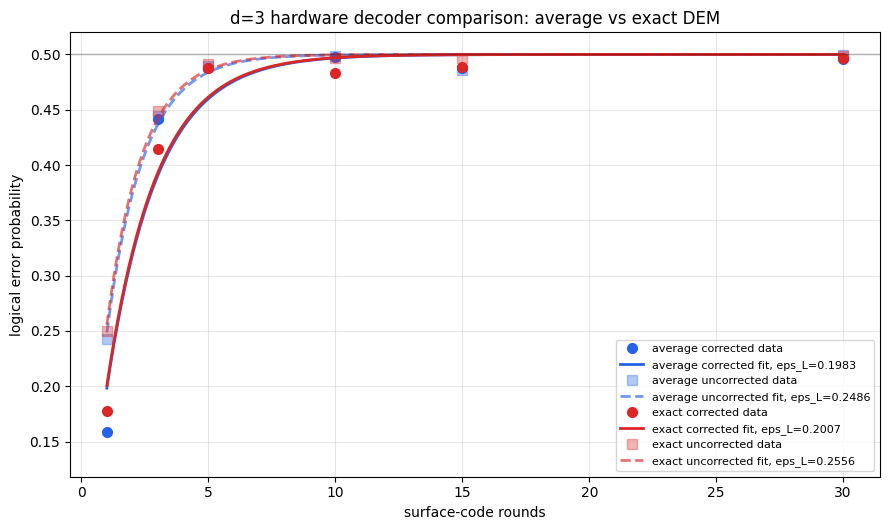

d=3 hardware decoder comparison
average DEM | corrected eps_L=0.19826 | uncorrected eps_L=0.24855 | swap_count=0
  exact DEM | corrected eps_L=0.20071 | uncorrected eps_L=0.25557 | swap_count=0


In [137]:
SCALING_ROUNDS = (1, 3, 5, 10, 15, 30)
SHOTS = 5000

d3_decoder_comparison = {}

for decoder_noise in ("average", "exact"):
    d3_decoder_comparison[decoder_noise] = iqm.run_round_sweep(
        distance=3,
        round_values=SCALING_ROUNDS,
        shots=SHOTS,
        basis=BASIS,
        cal=CAL,
        token=TOKEN,
        api_url=API_URL,
        run_mode="hardware",
        decoder_noise=decoder_noise,
        refresh_calibration=False,
        save_stim_file=False,
        optimize_layout=True,
        show_error_plot=False,
    )

# ---------------------------------------------------------------------
# Plot average vs exact detector error model comparison
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9.0, 5.4))

colors = {
    "average": "#2563eb",
    "exact": "#dc2626",
}

for decoder_noise, out in d3_decoder_comparison.items():
    fit = out["fit"]
    rounds = np.asarray(fit["rounds"], dtype=float)
    xs = np.linspace(rounds.min(), rounds.max(), 400)

    corrected_eps = fit["corrected_fit"]["epsilon_l"]
    uncorrected_eps = fit["uncorrected_fit"]["epsilon_l"]

    corrected_prob = fit["corrected_fit_prob"]
    uncorrected_prob = fit["uncorrected_fit_prob"]

    color = colors[decoder_noise]

    # Corrected data + fit
    ax.plot(
        rounds,
        corrected_prob,
        "o",
        color=color,
        markersize=7,
        label=f"{decoder_noise} corrected data",
    )
    ax.plot(
        xs,
        iqm.logical_error_probability(xs, corrected_eps),
        "-",
        color=color,
        linewidth=2.0,
        label=f"{decoder_noise} corrected fit, eps_L={corrected_eps:.4g}",
    )

    # Uncorrected data + fit
    ax.plot(
        rounds,
        uncorrected_prob,
        "s",
        color=color,
        alpha=0.35,
        markersize=7,
        label=f"{decoder_noise} uncorrected data",
    )
    ax.plot(
        xs,
        iqm.logical_error_probability(xs, uncorrected_eps),
        "--",
        color=color,
        alpha=0.65,
        linewidth=2.0,
        label=f"{decoder_noise} uncorrected fit, eps_L={uncorrected_eps:.4g}",
    )

ax.axhline(0.5, color="black", lw=1.0, alpha=0.25)

ax.set_xlabel("surface-code rounds")
ax.set_ylabel("logical error probability")
ax.set_title("d=3 hardware decoder comparison: average vs exact DEM")
ax.grid(True, alpha=0.3)

# Zoom to the relevant range while keeping the 0.5 saturation line visible
all_probs = []
for out in d3_decoder_comparison.values():
    fit = out["fit"]
    all_probs.extend(fit["corrected_fit_prob"])
    all_probs.extend(fit["uncorrected_fit_prob"])

y_min = max(0.0, min(all_probs) - 0.04)
ax.set_ylim(y_min, 0.52)

ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Print fitted logical error rates
# ---------------------------------------------------------------------

print("d=3 hardware decoder comparison")
print("=" * 60)

for decoder_noise, out in d3_decoder_comparison.items():
    s = out["summary"]
    print(
        f"{decoder_noise:>7} DEM | "
        f"corrected eps_L={s['logical_error_rate']:.5g} | "
        f"uncorrected eps_L={s['uncorrected_logical_error_rate']:.5g} | "
        f"swap_count={s.get('swap_count')}"
    )

The decoders are comparable, but interestingly the average one performs slightly better. This might be due to the exact detector error model overfitting the noise. However, if the calibration has been performed very recently, then the exact one might perform better. Since we are performing post-decoding, we can technically do both versions on every run and choose the one that works better.

# 3. Logical error rate comparison simulated on larger lattices

Let us see how our QEC pipeline scales with distance. Due to finite size of Emerald, let us use synthetic measuement data - this works the exact same way as on hardware but instead of getting measurement results from Emerald we are using the noise model of Emerald to sample measurement outcomes that would be comparable to Emerald. Synthetic mode is also useful for making sure the pipeline is correct. However, more interstingly, with our `synthetic` mode, we can push the distances we can reach to essentially simulate a larger quantum computer. 

rounds=1 | corrected_prob=0.028 | uncorrected_prob=0.116 | swap_count=None | skipped_ops=0 | job=None
rounds=2 | corrected_prob=0.051 | uncorrected_prob=0.1435 | swap_count=None | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.0555 | uncorrected_prob=0.1835 | swap_count=None | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.0905 | uncorrected_prob=0.2285 | swap_count=None | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.1315 | uncorrected_prob=0.3115 | swap_count=None | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.152 | uncorrected_prob=0.3205 | swap_count=None | skipped_ops=0 | job=None
rounds=15 | corrected_prob=0.2115 | uncorrected_prob=0.3935 | swap_count=None | skipped_ops=0 | job=None
rounds=20 | corrected_prob=0.234 | uncorrected_prob=0.4325 | swap_count=None | skipped_ops=0 | job=None
rounds=30 | corrected_prob=0.3285 | uncorrected_prob=0.4695 | swap_count=None | skipped_ops=0 | job=None
rounds=40 | corrected_prob=0.3715 | uncorrected_prob=0.4915 | swa

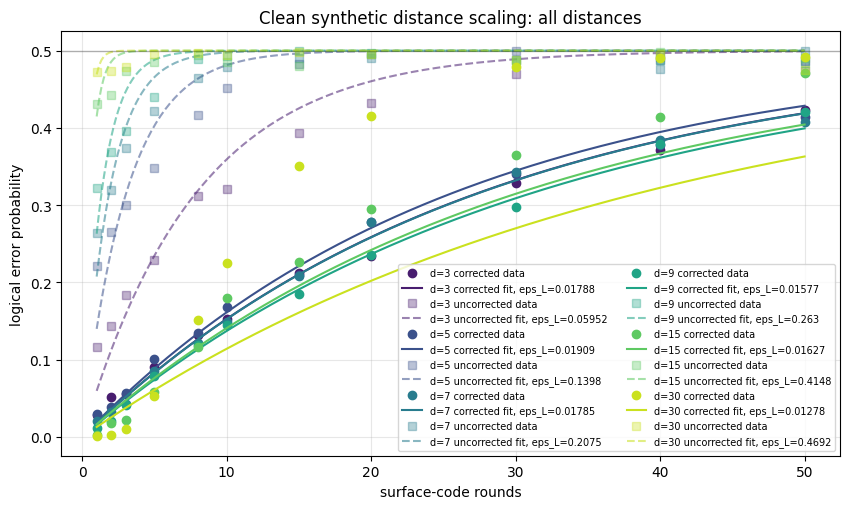

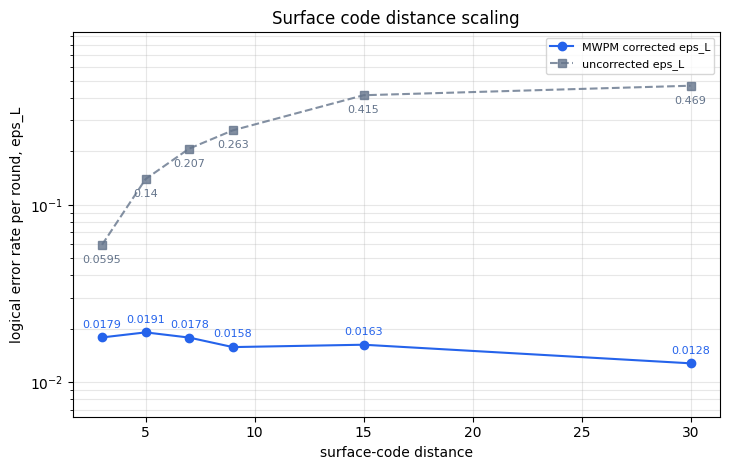

In [138]:

DISTANCES = (3, 5, 7, 9, 15, 30)
SCALING_ROUNDS = (1, 2, 3, 5, 8, 10, 15, 20, 30, 40, 50)
SCALING_SHOTS = 2_000          # increase for smoother final plots

clean_distance_results = {}
for distance in DISTANCES:
    clean_distance_results[distance] = iqm.run_round_sweep(
        distance=distance,
        round_values=SCALING_ROUNDS,
        shots=SCALING_SHOTS,
        basis="Z",
        cal=CAL,
        run_mode="synthetic",
        decoder_noise="average",
        refresh_calibration=False,
        save_stim_file=False,
        optimize_layout=False,
        show_error_plot=False,
    )



def print_ler_table(title, results_by_label):
    print("\n" + title)
    print("-" * len(title))
    for label, out in results_by_label.items():
        s = out["summary"]
        # print(
        #     f"{label}: corrected eps_L={s['logical_error_rate']:.5g}, "
        #     f"uncorrected eps_L={s['uncorrected_logical_error_rate']:.5g}"
        # )


def plot_distance_ler(clean_results, defect_results):
    """Plot fitted logical error rate per round vs distance on linear scale only."""
    distances = np.array(sorted(clean_results), dtype=float)
    clean_corr = np.array([clean_results[int(d)]["summary"]["logical_error_rate"] for d in distances])
    clean_unc = np.array([clean_results[int(d)]["summary"]["uncorrected_logical_error_rate"] for d in distances])
    defect_corr = np.array([defect_results[int(d)]["summary"]["logical_error_rate"] for d in distances])
    defect_unc = np.array([defect_results[int(d)]["summary"]["uncorrected_logical_error_rate"] for d in distances])

    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    ax.plot(distances, clean_corr, "o-", label="clean, MWPM corrected")
    ax.plot(distances, clean_unc, "o--", label="clean, uncorrected")
    ax.plot(distances, defect_corr, "s-", label="SnL one defect, MWPM corrected")
    ax.plot(distances, defect_unc, "s--", label="SnL one defect, uncorrected")
    for xs, ys in [(distances, clean_corr), (distances, clean_unc), (distances, defect_corr), (distances, defect_unc)]:
        for x0, y0 in zip(xs, ys):
            ax.annotate(f"{y0:.3g}", (x0, y0), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
    ax.set_xlabel("surface-code distance")
    ax.set_ylabel("logical error rate per round")
    ax.set_title("Distance scaling with calibration-derived noise")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    return fig


print_ler_table("Clean synthetic distance scaling", {str(k): v for k, v in clean_distance_results.items()})
fig, ax = plt.subplots(figsize=(8.6, 5.2))
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(clean_distance_results)))
for color, distance in zip(colors, sorted(clean_distance_results)):
    out = clean_distance_results[distance]
    fit = out["fit"]
    rounds = np.asarray(fit["rounds"], dtype=float)
    xs = np.linspace(rounds.min(), rounds.max(), 300)
    corrected_eps = fit["corrected_fit"]["epsilon_l"]
    uncorrected_eps = fit["uncorrected_fit"]["epsilon_l"]

    ax.plot(
        rounds,
        fit["corrected_fit_prob"],
        "o",
        color=color,
        label=f"d={distance} corrected data",
    )
    ax.plot(
        xs,
        iqm.logical_error_probability(xs, corrected_eps),
        "-",
        color=color,
        label=f"d={distance} corrected fit, eps_L={corrected_eps:.4g}",
    )
    ax.plot(
        rounds,
        fit["uncorrected_fit_prob"],
        "s",
        color=color,
        alpha=0.35,
        label=f"d={distance} uncorrected data",
    )
    ax.plot(
        xs,
        iqm.logical_error_probability(xs, uncorrected_eps),
        "--",
        color=color,
        alpha=0.55,
        label=f"d={distance} uncorrected fit, eps_L={uncorrected_eps:.4g}",
    )

ax.axhline(0.5, color="black", lw=1, alpha=0.25)
ax.set_xlabel("surface-code rounds")
ax.set_ylabel("logical error probability")
ax.set_title("Clean synthetic distance scaling: all distances")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=7, ncols=2)
fig.tight_layout()
plt.show()

# Log-scale distance trend: fitted logical error rate per round vs code distance.
distances = np.array(sorted(clean_distance_results), dtype=float)
corrected_ler = np.array([clean_distance_results[int(d)]["summary"]["logical_error_rate"] for d in distances])
uncorrected_ler = np.array([clean_distance_results[int(d)]["summary"]["uncorrected_logical_error_rate"] for d in distances])

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(distances, corrected_ler, "o-", color="#2563eb", label="MWPM corrected eps_L")
ax.plot(distances, uncorrected_ler, "s--", color="#64748b", alpha=0.8, label="uncorrected eps_L")
for x0, y0 in zip(distances, corrected_ler):
    ax.annotate(f"{y0:.3g}", (x0, y0), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8, color="#2563eb")
for x0, y0 in zip(distances, uncorrected_ler):
    ax.annotate(f"{y0:.3g}", (x0, y0), textcoords="offset points", xytext=(0, -13), ha="center", fontsize=8, color="#64748b")
positive = np.concatenate([corrected_ler[corrected_ler > 0], uncorrected_ler[uncorrected_ler > 0]])
if len(positive):
    ax.set_yscale("log")
    ax.set_ylim(max(positive.min() / 2, 1e-8), min(positive.max() * 2, 1.0))
ax.set_xlabel("surface-code distance")
ax.set_ylabel("logical error rate per round, eps_L")
ax.set_title("Surface code distance scaling")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

# 4. Snakes-and-Ladders defective-lattice simulations  

In general we can have 3 types of defects:
- data qubit defect (worst type of defect)
- ancilla qubit defect 
- coupler defect

In the previous section we looked at a faulty coupler. Next let us use our pipeline with a defective data qubit in the center. We mark central `QB27` as unavailable. Below, we show the logical error rates as well as how the stabilizers are deformed. The deformed stabilizers around the defect are called "super stabilizers" since the stabilizer around the defect becomes quite large (combined weight 6), compared to the normal weight 4.

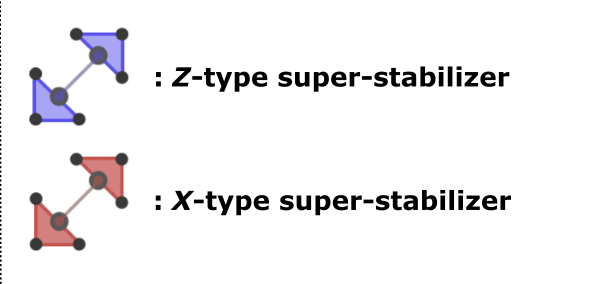

Loaded today's calibration data: calibration_data/2026-06-08T06_12_52.097243Z.json
Found 1 defect clusters.
rounds=1 | logical_error_probability=0.0766 | uncorrected=0.2882 | swap_count=None | job=None
rounds=3 | logical_error_probability=0.117 | uncorrected=0.3334 | swap_count=None | job=None
rounds=5 | logical_error_probability=0.1476 | uncorrected=0.3816 | swap_count=None | job=None
rounds=8 | logical_error_probability=0.1838 | uncorrected=0.4206 | swap_count=None | job=None
rounds=10 | logical_error_probability=0.2058 | uncorrected=0.4312 | swap_count=None | job=None
rounds=15 | logical_error_probability=0.277 | uncorrected=0.4716 | swap_count=None | job=None
rounds=20 | logical_error_probability=0.3234 | uncorrected=0.4788 | swap_count=None | job=None


{'distance': 5,
 'round_values': [1, 3, 5, 8, 10, 15, 20],
 'shots': 5000,
 'mode': 'synthetic',
 'effective_distance': (4, 4),
 'defect_qubits': [27],
 'defect_couplers': [],
 'use_calibration_defects': False,
 'optimize_layout': True,
 'sw_offset': (1, 1),
 'logical_error_rate': 0.02889008667043335,
 'uncorrected_logical_error_rate': 0.17469552408762043,
 'swap_count': None,
 'skipped_hardware_operation_count': 0}

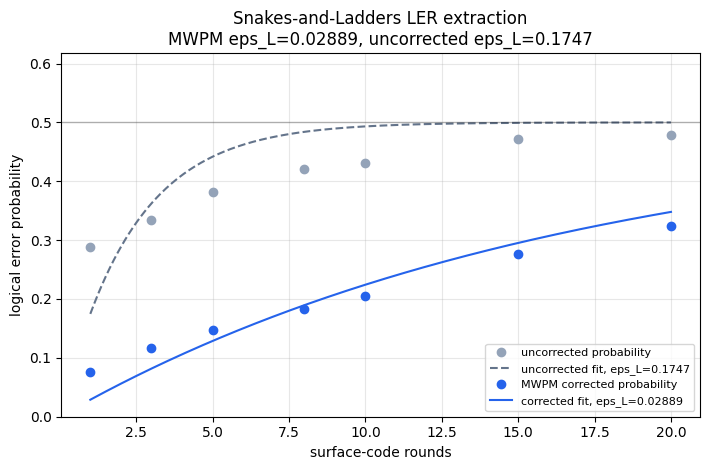

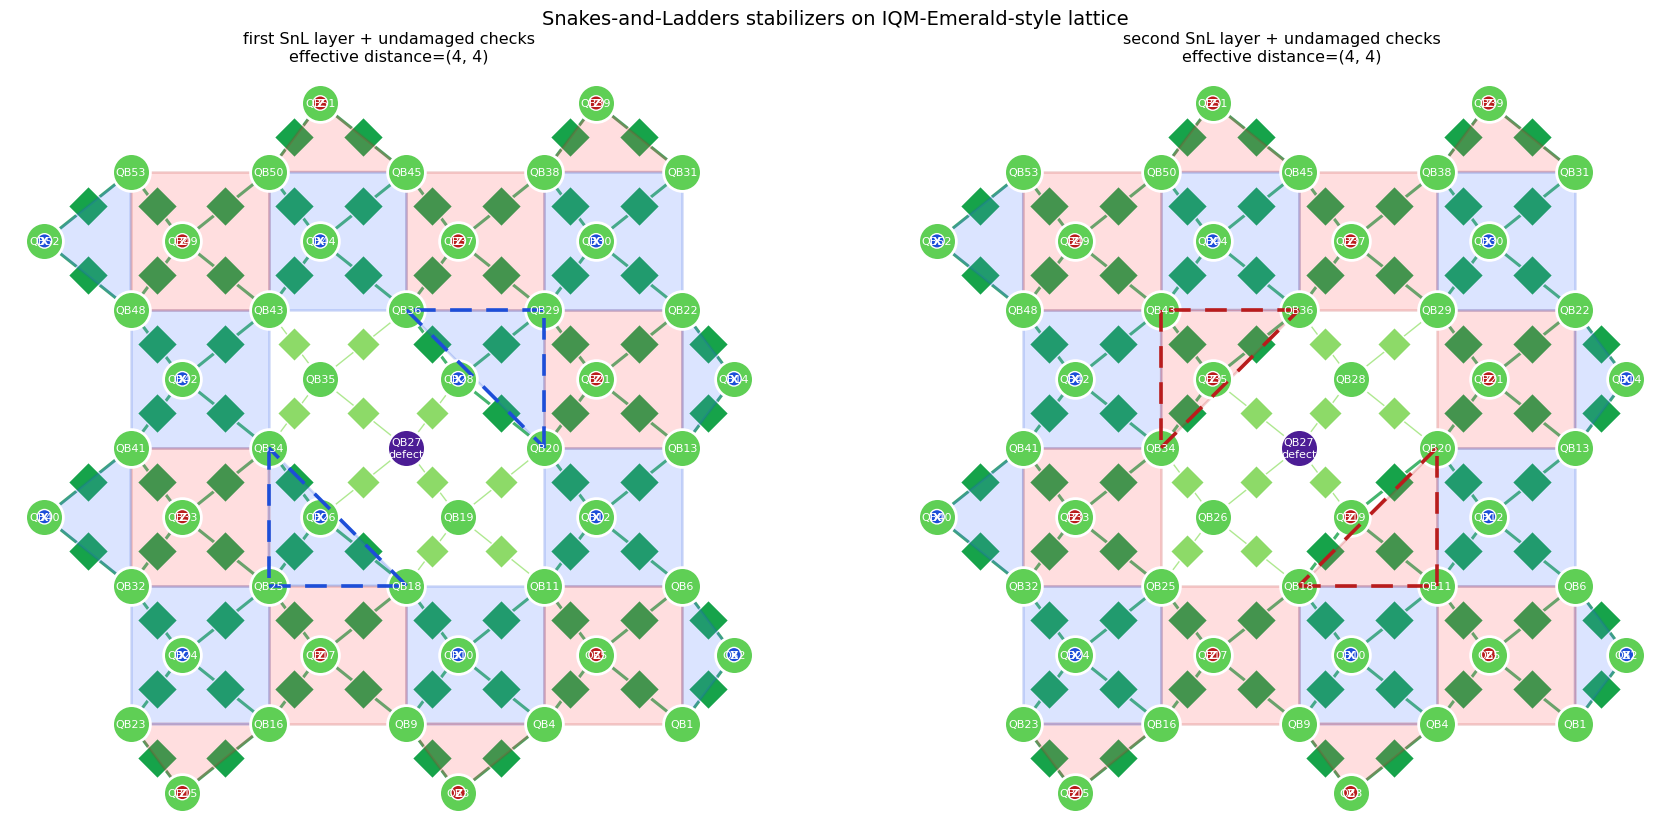

In [139]:
snl_d5_center_defect = snl.run_snl_round_sweep(
    distance=5,
    round_values=ROUND_VALUES,
    shots=SHOTS,
    mode="synthetic",
    defect_qubits=[27],
    use_calibration_defects=False,
    basis=BASIS,
    cal=CAL,
    optimize_layout=True,
    show_lattice_plot=True,
    show_error_plot=True,
)

snl_d5_center_defect["summary"]


Let us compare the performance when we are using our SnL pipeline vs not for the d=5 surface code. Use the center data qubit defect.

Loaded today's calibration data: calibration_data/2026-06-08T06_12_52.097243Z.json
Found 1 defect clusters.
rounds=3 | logical_error_probability=0.1096 | uncorrected=0.3378 | swap_count=None | job=None
rounds=5 | logical_error_probability=0.1524 | uncorrected=0.3796 | swap_count=None | job=None
rounds=7 | logical_error_probability=0.184 | uncorrected=0.4082 | swap_count=None | job=None
rounds=10 | logical_error_probability=0.2158 | uncorrected=0.4368 | swap_count=None | job=None
rounds=15 | logical_error_probability=0.2778 | uncorrected=0.4738 | swap_count=None | job=None
rounds=20 | logical_error_probability=0.3212 | uncorrected=0.4872 | swap_count=None | job=None
rounds=25 | logical_error_probability=0.3732 | uncorrected=0.4984 | swap_count=None | job=None
rounds=30 | logical_error_probability=0.3792 | uncorrected=0.502 | swap_count=None | job=None
rounds=35 | logical_error_probability=0.413 | uncorrected=0.5014 | swap_count=None | job=None
rounds=40 | logical_error_probability=0.426

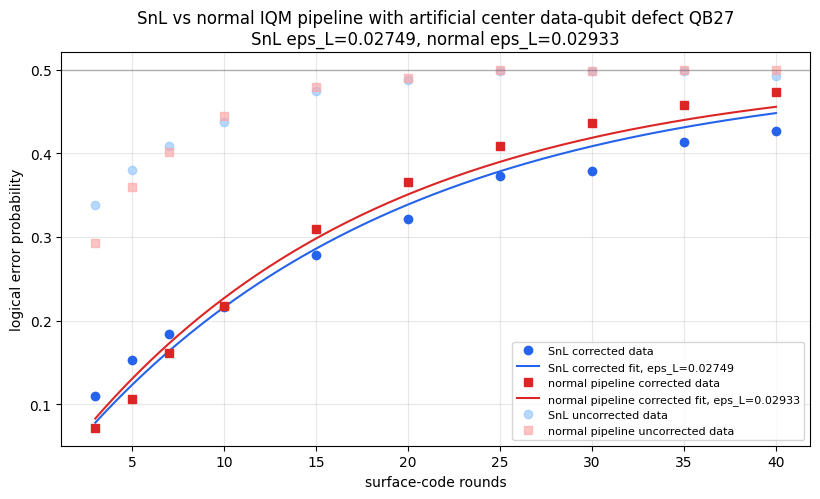

{'defect_iqm_qubit': 27,
 'defect_stim_qubit': 35,
 'defect_depolarization': 0.6,
 'snl_corrected_logical_error_rate': 0.02749258247791239,
 'normal_pipeline_corrected_logical_error_rate': 0.02933008799043995,
 'snl_uncorrected_logical_error_rate': 0.12851038553192765,
 'normal_pipeline_uncorrected_logical_error_rate': 0.11331783995419976}

In [140]:
# Compare SnL deformation against the normal IQM pipeline on the same artificial center defect.
#
# SnL:
#   Treat the center data qubit as unavailable and deform stabilizers around it.
# Normal IQM pipeline:
#   Keep the ordinary rotated surface-code stabilizers/layout, but in synthetic mode
#   add strong defect noise to the same center Stim data qubit.

ROUND_VALUES = (3, 5, 7, 10, 15, 20, 25, 30, 35, 40)
DEFECT_DEPOLARIZATION = 0.6

snl_d5_center_defect = snl.run_snl_round_sweep(
    distance=5,
    round_values=ROUND_VALUES,
    shots=SHOTS,
    mode="synthetic",
    defect_qubits=[27],
    use_calibration_defects=False,
    basis=BASIS,
    cal=CAL,
    optimize_layout=False,
    show_lattice_plot=False,
    show_error_plot=False,
)

snl_reference_result = snl_d5_center_defect["results"][0]
center_defect_pos = next(iter(snl_reference_result["data_defects"]))
center_defect_stim_q = int(center_defect_pos)
center_defect_iqm_q = snl.COORD_TO_QB[center_defect_pos]
print(f"Same artificial center defect: Stim q={center_defect_stim_q}, IQM QB{center_defect_iqm_q}")

no_snl_center_defect = iqm.run_round_sweep(
    distance=5,
    round_values=ROUND_VALUES,
    shots=SHOTS,
    basis=BASIS,
    cal=CAL,
    run_mode="synthetic",
    decoder_noise="average",
    refresh_calibration=False,
    save_stim_file=False,
    optimize_layout=False,
    synthetic_defect_qubits=[center_defect_stim_q],
    synthetic_defect_probability=DEFECT_DEPOLARIZATION,
    show_error_plot=False,
)

snl_fit = snl_d5_center_defect["fit"]
no_snl_fit = no_snl_center_defect["fit"]
snl_rounds = np.asarray(snl_fit["rounds"], dtype=float)
no_snl_rounds = np.asarray(no_snl_fit["rounds"], dtype=float)
xs = np.linspace(min(snl_rounds.min(), no_snl_rounds.min()), max(snl_rounds.max(), no_snl_rounds.max()), 300)

fig, ax = plt.subplots(figsize=(8.3, 5.1))
ax.plot(snl_rounds, snl_fit["corrected_fit_prob"], "o", color="#2563eb", label="SnL corrected data")
ax.plot(
    xs,
    iqm.logical_error_probability(xs, snl_fit["corrected_fit"]["epsilon_l"]),
    "-",
    color="#2563eb",
    label=f"SnL corrected fit, eps_L={snl_fit['corrected_fit']['epsilon_l']:.4g}",
)
ax.plot(no_snl_rounds, no_snl_fit["corrected_fit_prob"], "s", color="#dc2626", label="normal pipeline corrected data")
ax.plot(
    xs,
    iqm.logical_error_probability(xs, no_snl_fit["corrected_fit"]["epsilon_l"]),
    "-",
    color="#dc2626",
    label=f"normal pipeline corrected fit, eps_L={no_snl_fit['corrected_fit']['epsilon_l']:.4g}",
)
ax.plot(snl_rounds, snl_fit["uncorrected_fit_prob"], "o", color="#93c5fd", alpha=0.65, label="SnL uncorrected data")
ax.plot(no_snl_rounds, no_snl_fit["uncorrected_fit_prob"], "s", color="#fca5a5", alpha=0.65, label="normal pipeline uncorrected data")
ax.axhline(0.5, color="black", lw=1, alpha=0.25)
ax.set_xlabel("surface-code rounds")
ax.set_ylabel("logical error probability")
ax.set_title(
    f"SnL vs normal IQM pipeline with artificial center data-qubit defect QB{center_defect_iqm_q}\n"
    f"SnL eps_L={snl_fit['corrected_fit']['epsilon_l']:.4g}, normal eps_L={no_snl_fit['corrected_fit']['epsilon_l']:.4g}"
)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

comparison_summary = {
    "defect_iqm_qubit": center_defect_iqm_q,
    "defect_stim_qubit": center_defect_stim_q,
    "defect_depolarization": DEFECT_DEPOLARIZATION,
    "snl_corrected_logical_error_rate": snl_fit["corrected_fit"]["epsilon_l"],
    "normal_pipeline_corrected_logical_error_rate": no_snl_fit["corrected_fit"]["epsilon_l"],
    "snl_uncorrected_logical_error_rate": snl_fit["uncorrected_fit"]["epsilon_l"],
    "normal_pipeline_uncorrected_logical_error_rate": no_snl_fit["uncorrected_fit"]["epsilon_l"],
}
comparison_summary


### Let's add more defects!

Adding random defects on the synthetic d=9 lattice to compare the normal pipeline against the Snakes-and-Ladders deformation pipeline.


Found 0 defect clusters.

=== d=9 random defects n=0 | data defects=0 | coupler defects=0 ===
Stim data-qubit defects: []
Stim coupler defects: []
rounds=1 | corrected_prob=0.012 | uncorrected_prob=0.311 | swap_count=None | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.037 | uncorrected_prob=0.377 | swap_count=None | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.052 | uncorrected_prob=0.432 | swap_count=None | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.119 | uncorrected_prob=0.482 | swap_count=None | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.122 | uncorrected_prob=0.49 | swap_count=None | skipped_ops=0 | job=None


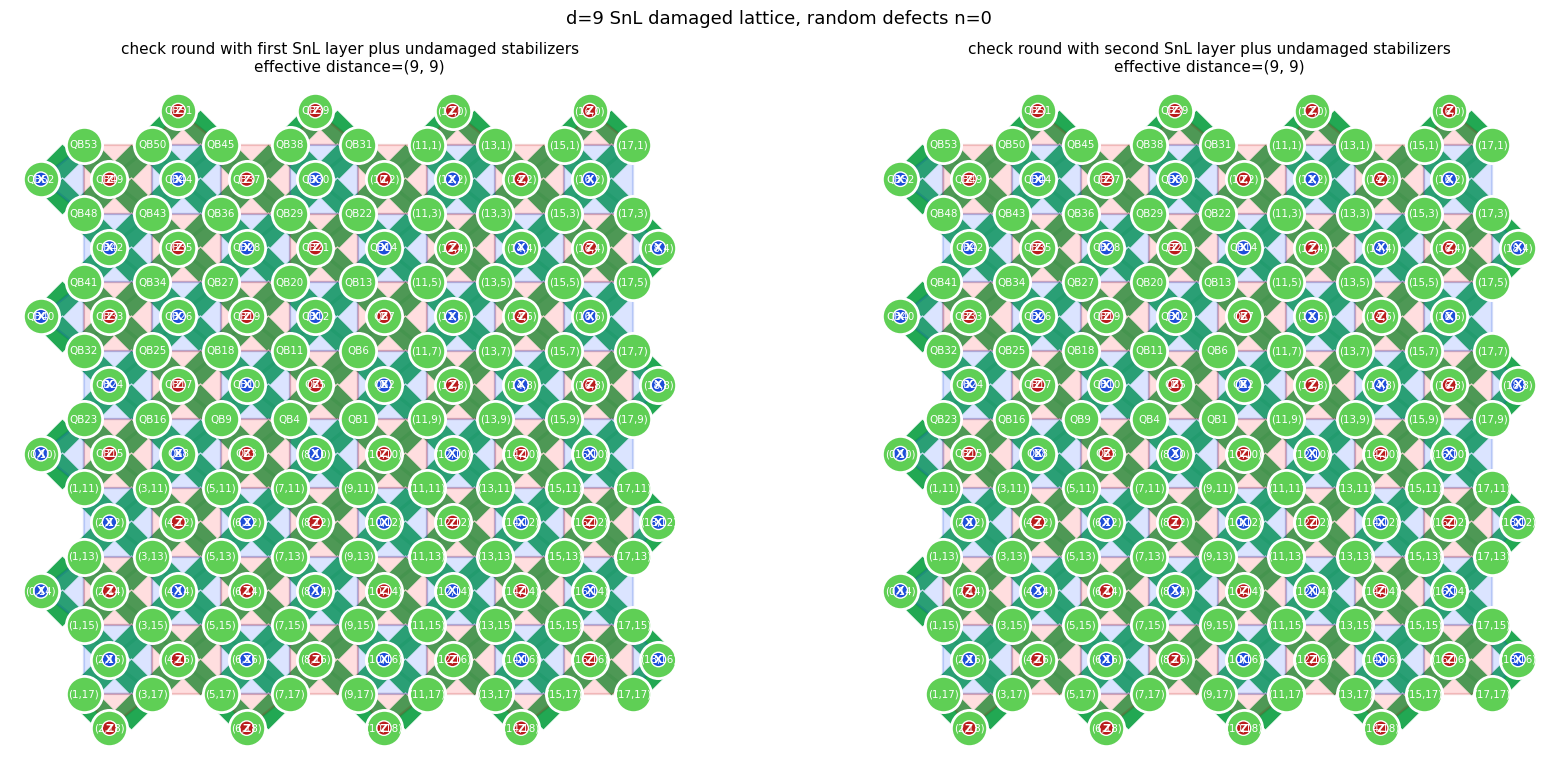

Found 1 defect clusters.

=== d=9 random defects n=1 | data defects=0 | coupler defects=1 ===
Stim data-qubit defects: []
Stim coupler defects: [(83, 101)]
rounds=1 | corrected_prob=0.014 | uncorrected_prob=0.327 | swap_count=None | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.047 | uncorrected_prob=0.39 | swap_count=None | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.097 | uncorrected_prob=0.45 | swap_count=None | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.141 | uncorrected_prob=0.459 | swap_count=None | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.2 | uncorrected_prob=0.478 | swap_count=None | skipped_ops=0 | job=None


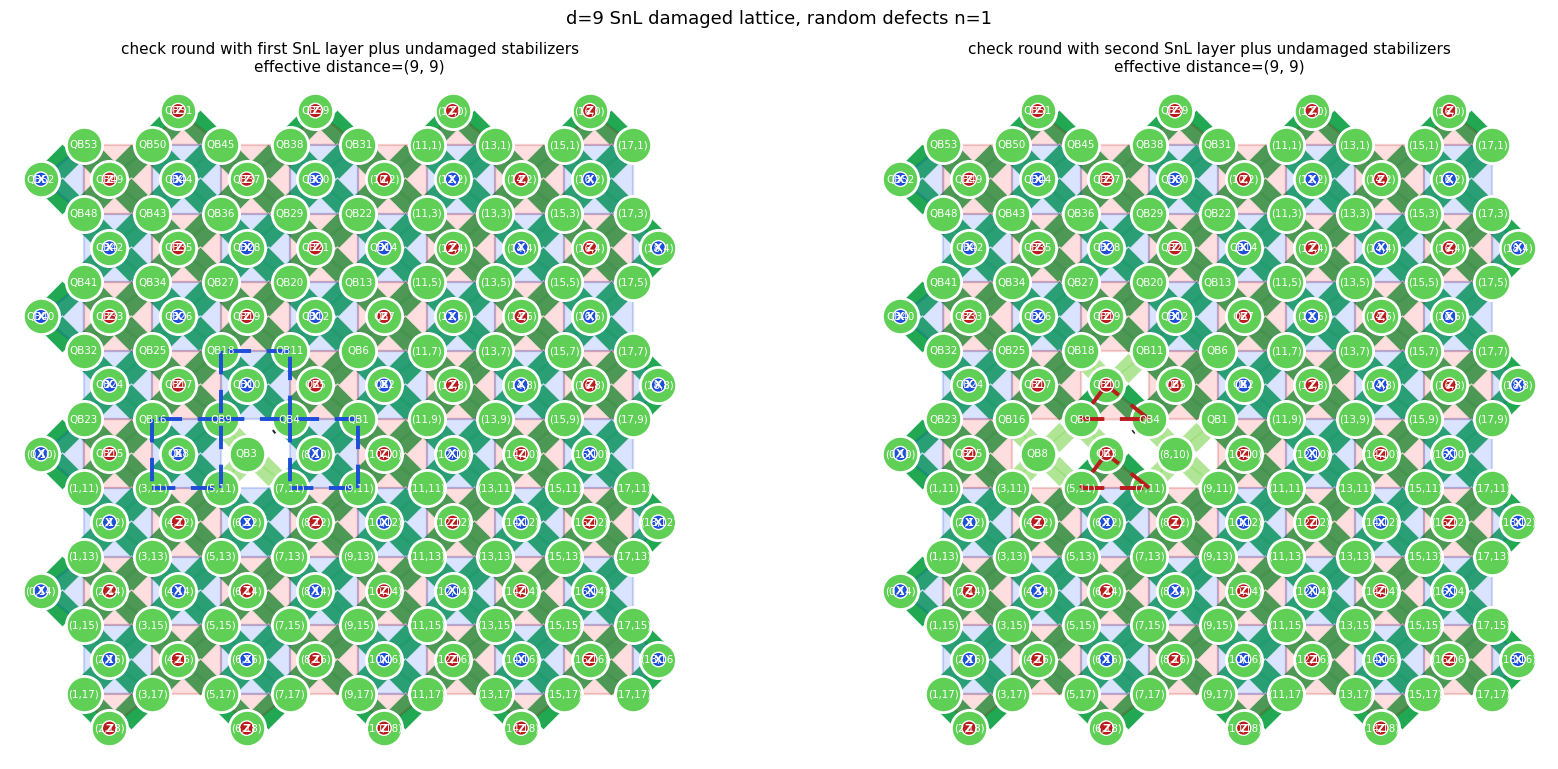

Found 2 defect clusters.

=== d=9 random defects n=2 | data defects=2 | coupler defects=0 ===
Stim data-qubit defects: [49, 138]
Stim coupler defects: []
rounds=1 | corrected_prob=0.015 | uncorrected_prob=0.302 | swap_count=None | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.071 | uncorrected_prob=0.391 | swap_count=None | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.123 | uncorrected_prob=0.436 | swap_count=None | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.185 | uncorrected_prob=0.492 | swap_count=None | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.25 | uncorrected_prob=0.478 | swap_count=None | skipped_ops=0 | job=None


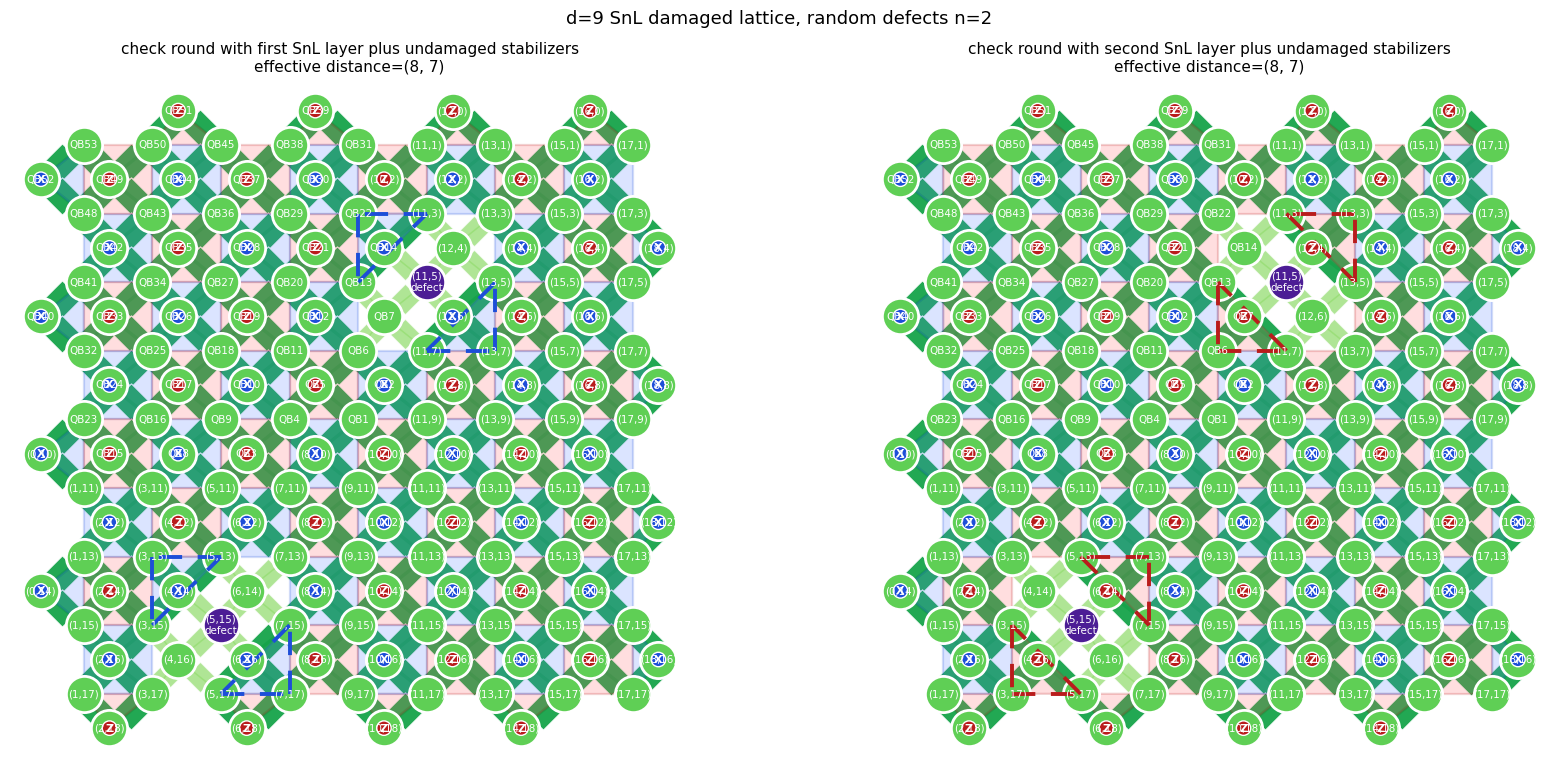

Found 2 defect clusters.

=== d=9 random defects n=3 | data defects=2 | coupler defects=1 ===
Stim data-qubit defects: [51, 100]
Stim coupler defects: [(66, 84)]
rounds=1 | corrected_prob=0.021 | uncorrected_prob=0.311 | swap_count=None | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.075 | uncorrected_prob=0.412 | swap_count=None | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.156 | uncorrected_prob=0.457 | swap_count=None | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.224 | uncorrected_prob=0.473 | swap_count=None | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.299 | uncorrected_prob=0.467 | swap_count=None | skipped_ops=0 | job=None


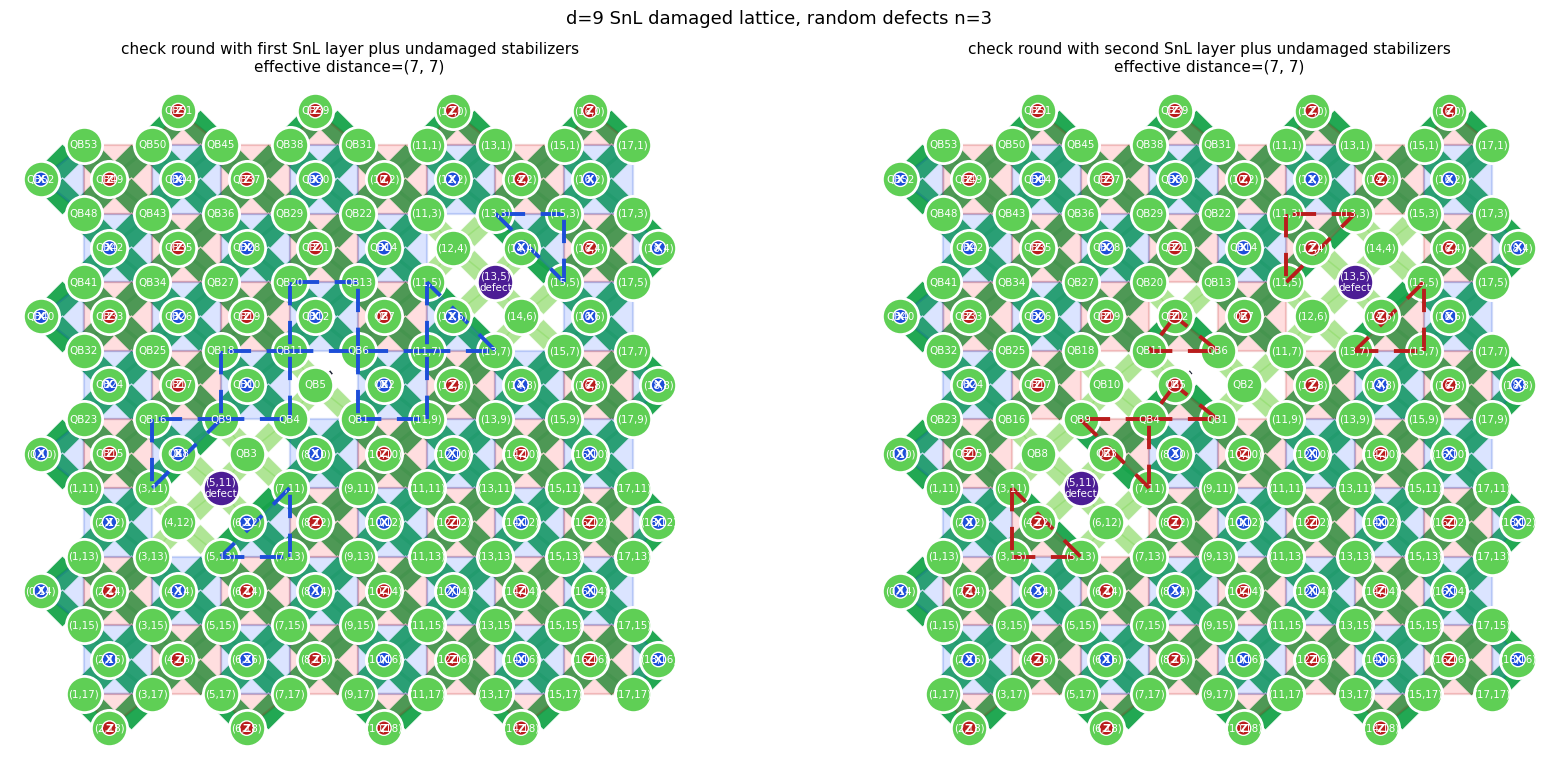

Found 2 defect clusters.

=== d=9 random defects n=4 | data defects=3 | coupler defects=1 ===
Stim data-qubit defects: [79, 98, 117]
Stim coupler defects: [(68, 86)]
rounds=1 | corrected_prob=0.023 | uncorrected_prob=0.321 | swap_count=None | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.08 | uncorrected_prob=0.373 | swap_count=None | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.136 | uncorrected_prob=0.431 | swap_count=None | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.232 | uncorrected_prob=0.482 | swap_count=None | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.308 | uncorrected_prob=0.492 | swap_count=None | skipped_ops=0 | job=None


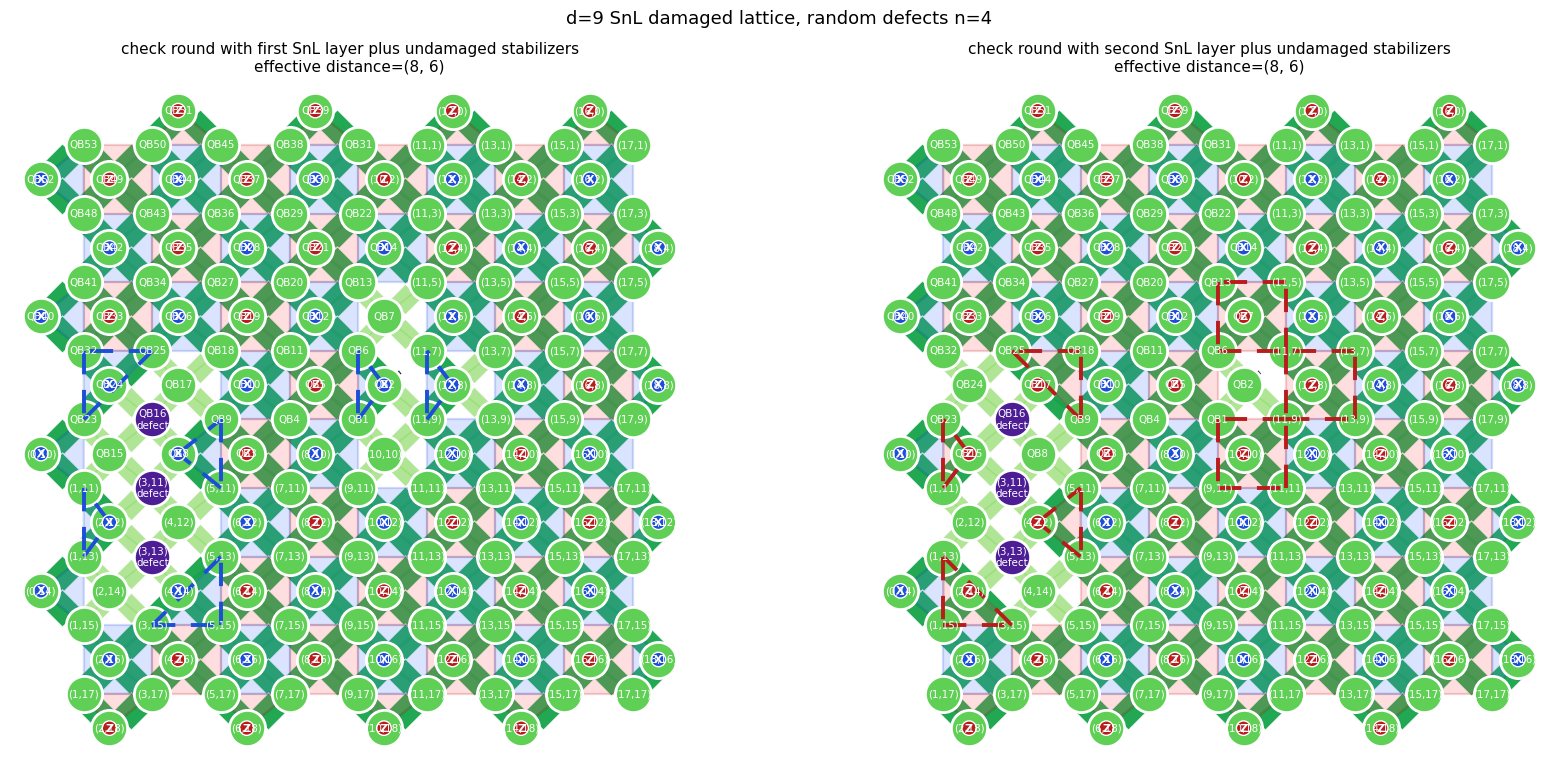

Found 1 defect clusters.

=== d=9 random defects n=5 | data defects=1 | coupler defects=4 ===
Stim data-qubit defects: [110]
Stim coupler defects: [(68, 88), (70, 88), (121, 122), (138, 158)]
rounds=1 | corrected_prob=0.025 | uncorrected_prob=0.319 | swap_count=None | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.093 | uncorrected_prob=0.381 | swap_count=None | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.153 | uncorrected_prob=0.475 | swap_count=None | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.255 | uncorrected_prob=0.466 | swap_count=None | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.294 | uncorrected_prob=0.501 | swap_count=None | skipped_ops=0 | job=None


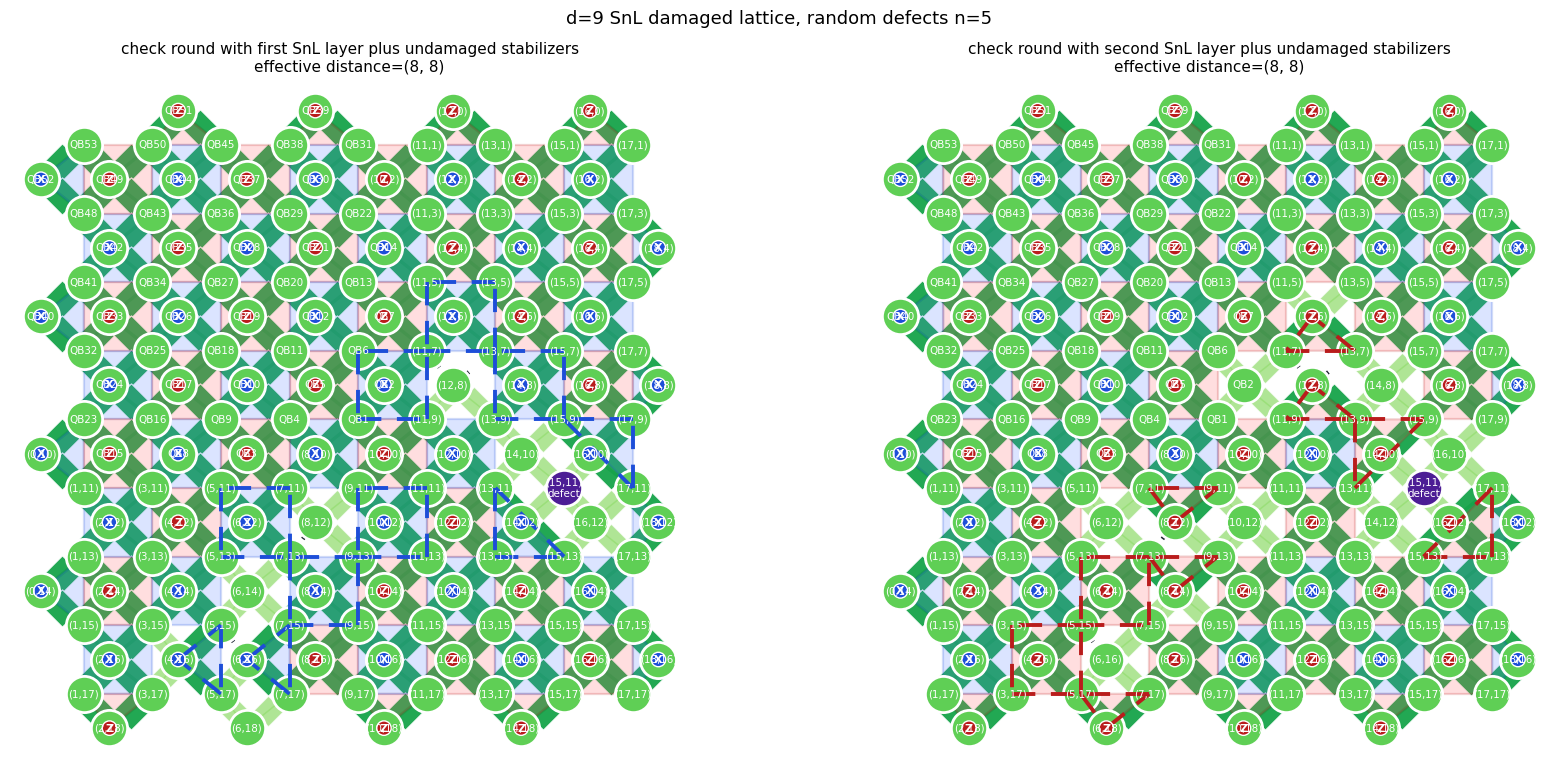

Found 1 defect clusters.

=== d=9 random defects n=6 | data defects=4 | coupler defects=2 ===
Stim data-qubit defects: [62, 79, 83, 85]
Stim coupler defects: [(41, 59), (61, 62)]
rounds=1 | corrected_prob=0.024 | uncorrected_prob=0.315 | swap_count=None | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.092 | uncorrected_prob=0.386 | swap_count=None | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.167 | uncorrected_prob=0.456 | swap_count=None | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.275 | uncorrected_prob=0.474 | swap_count=None | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.304 | uncorrected_prob=0.491 | swap_count=None | skipped_ops=0 | job=None


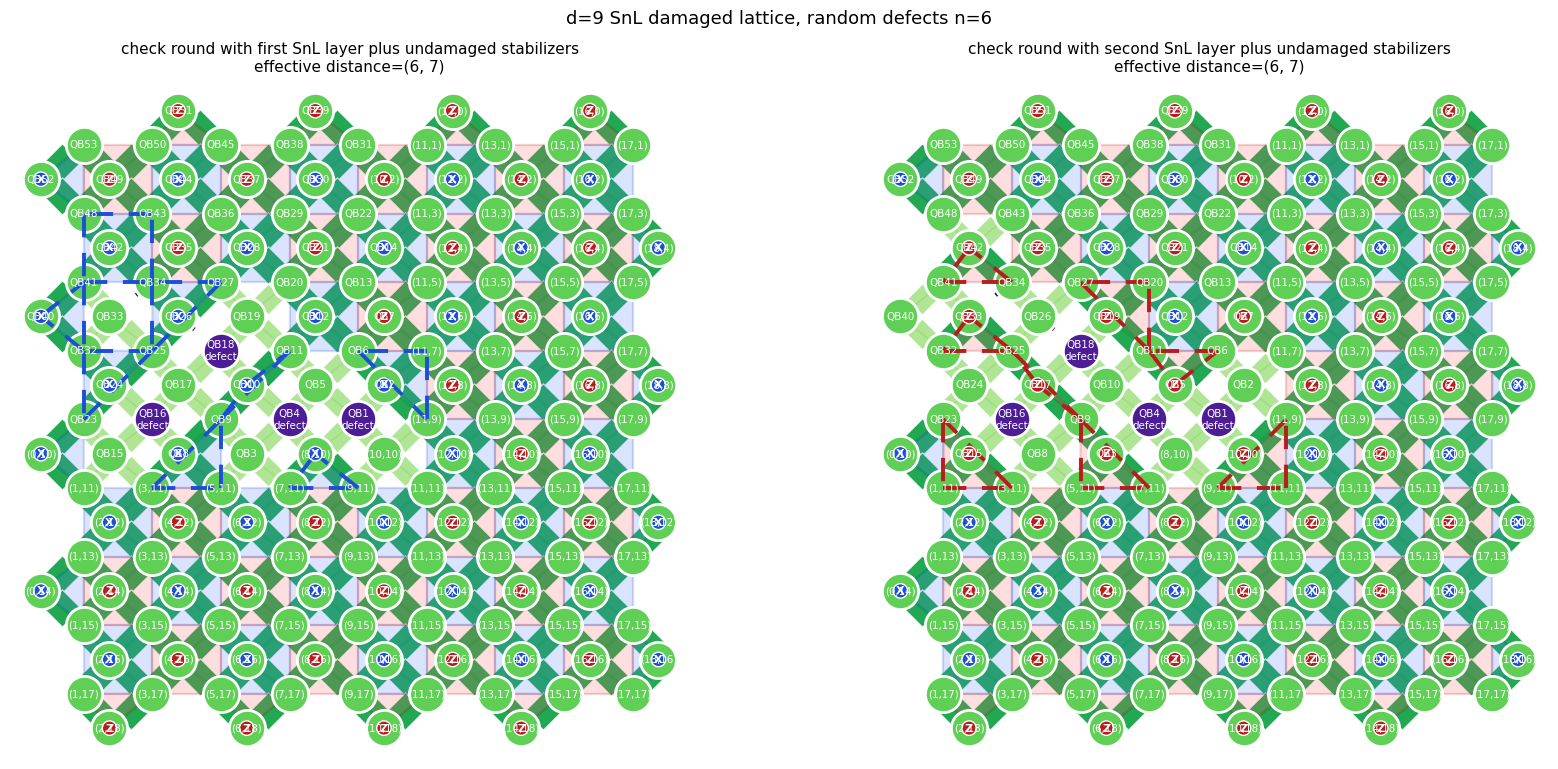

Found 4 defect clusters.

=== d=9 random defects n=7 | data defects=2 | coupler defects=5 ===
Stim data-qubit defects: [129, 142]
Stim coupler defects: [(24, 42), (59, 60), (90, 91), (119, 139), (138, 158)]
rounds=1 | corrected_prob=0.033 | uncorrected_prob=0.31 | swap_count=None | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.115 | uncorrected_prob=0.401 | swap_count=None | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.184 | uncorrected_prob=0.463 | swap_count=None | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.275 | uncorrected_prob=0.451 | swap_count=None | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.327 | uncorrected_prob=0.482 | swap_count=None | skipped_ops=0 | job=None


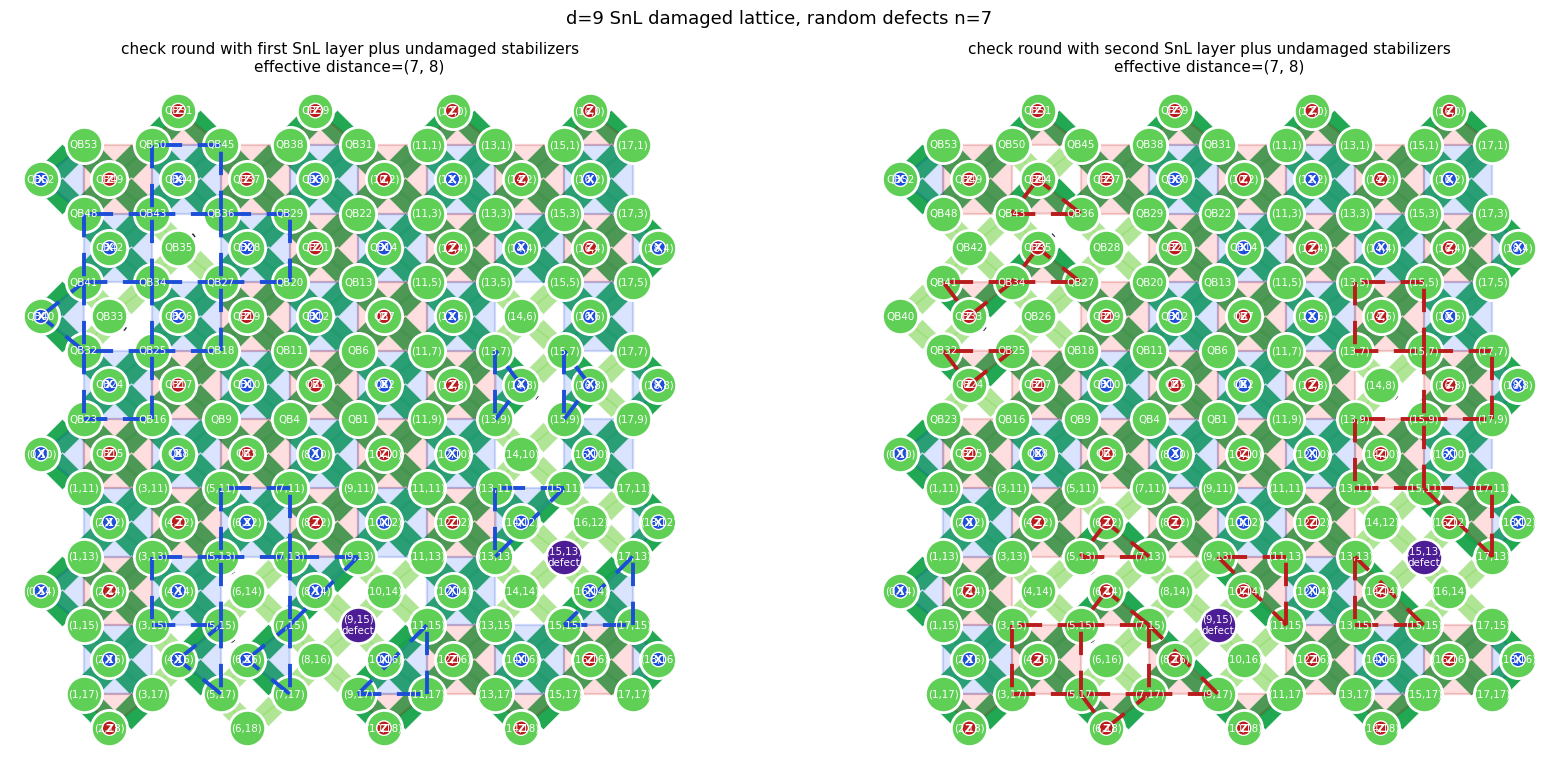

Found 3 defect clusters.

=== d=9 random defects n=8 | data defects=3 | coupler defects=5 ===
Stim data-qubit defects: [68, 102, 129]
Stim coupler defects: [(49, 67), (118, 119), (124, 125), (129, 130), (138, 158)]
rounds=1 | corrected_prob=0.032 | uncorrected_prob=0.331 | swap_count=None | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.127 | uncorrected_prob=0.378 | swap_count=None | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.215 | uncorrected_prob=0.432 | swap_count=None | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.358 | uncorrected_prob=0.499 | swap_count=None | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.398 | uncorrected_prob=0.486 | swap_count=None | skipped_ops=0 | job=None


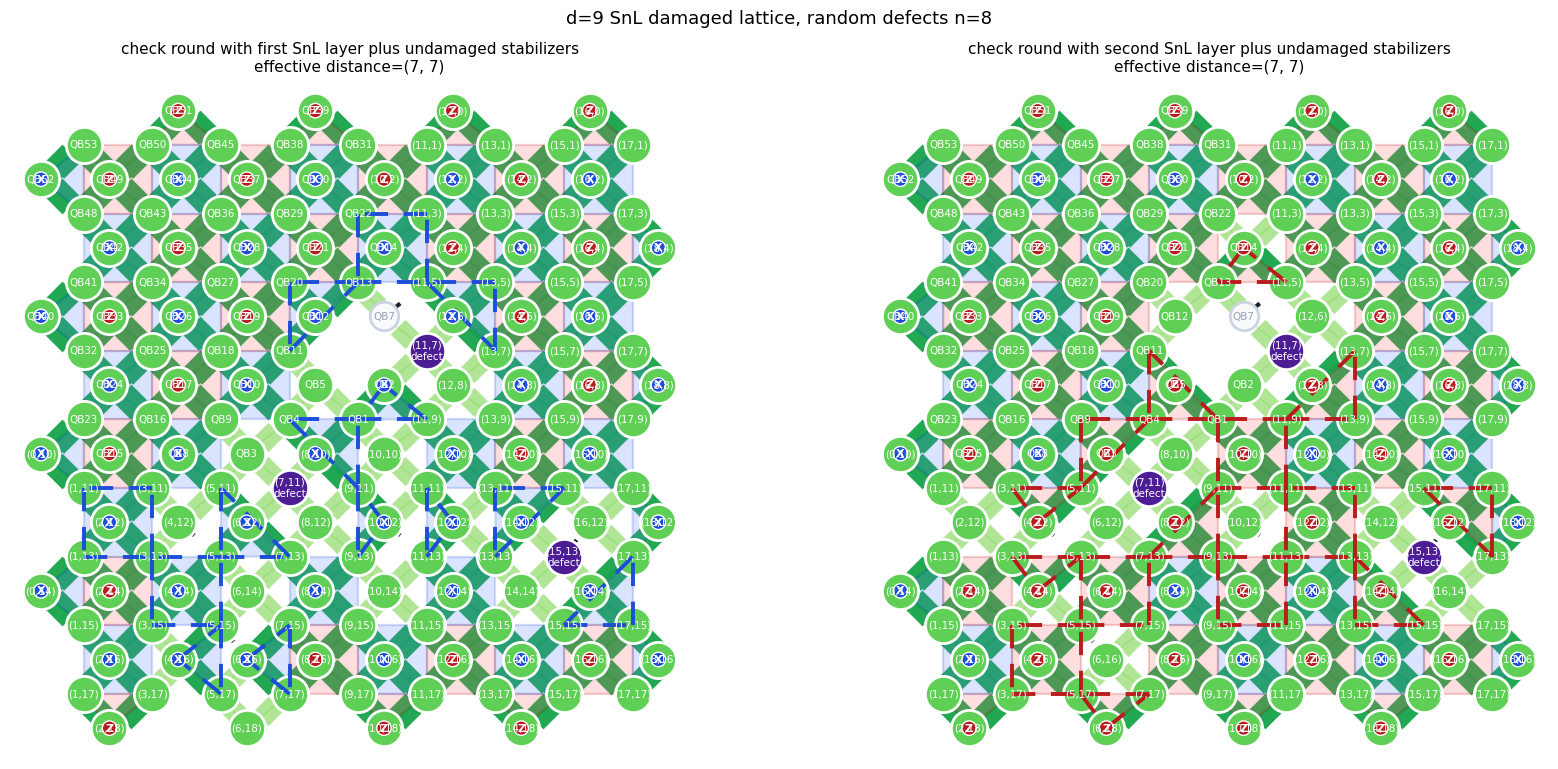

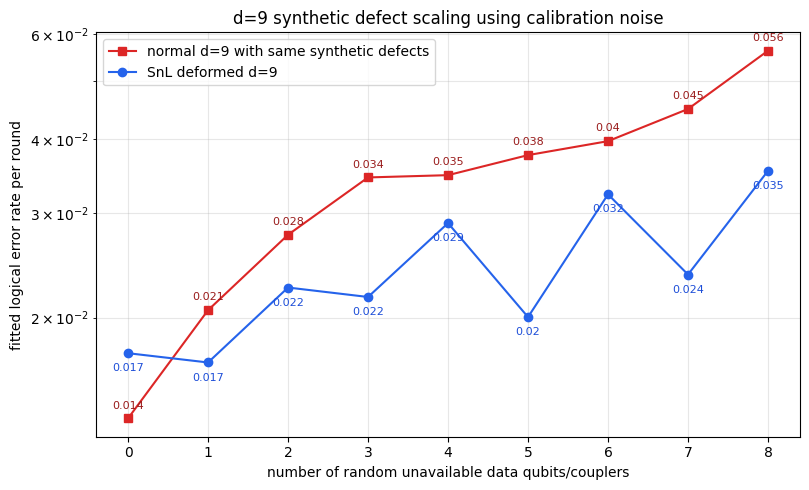


Fitted logical error rates per round
n=0: SnL eps_L=0.01743, normal eps_L=0.01354, data defects=[], coupler defects=[]
n=1: SnL eps_L=0.01681, normal eps_L=0.02059, data defects=[], coupler defects=[(83, 101)]
n=2: SnL eps_L=0.02248, normal eps_L=0.02758, data defects=[49, 138], coupler defects=[]
n=3: SnL eps_L=0.02167, normal eps_L=0.03444, data defects=[51, 100], coupler defects=[(66, 84)]
n=4: SnL eps_L=0.02885, normal eps_L=0.03474, data defects=[79, 98, 117], coupler defects=[(68, 86)]
n=5: SnL eps_L=0.02005, normal eps_L=0.03755, data defects=[110], coupler defects=[(68, 88), (70, 88), (121, 122), (138, 158)]
n=6: SnL eps_L=0.03225, normal eps_L=0.03964, data defects=[62, 79, 83, 85], coupler defects=[(41, 59), (61, 62)]
n=7: SnL eps_L=0.02364, normal eps_L=0.0449, data defects=[129, 142], coupler defects=[(24, 42), (59, 60), (90, 91), (119, 139), (138, 158)]
n=8: SnL eps_L=0.03533, normal eps_L=0.05628, data defects=[68, 102, 129], coupler defects=[(49, 67), (118, 119), (124, 

In [141]:
# d=9 random-defect scaling demo: normal pipeline vs Snakes-and-Ladders.
# Each n draws n random unavailable objects inside the d=9 patch. Each object is
# randomly either a data qubit or a data-ancilla coupler. The SnL pipeline deforms
# the checks around those defects; the normal pipeline keeps the same d=9 layout
# but injects strong synthetic noise on the same qubits/couplers.

D9_DEFECT_DISTANCE = 9
D9_DEFECT_COUNTS = range(0, 9)
D9_ROUND_VALUES = (1, 3, 5, 8, 10)
D9_SHOTS = 1_000              # increase for smoother final numbers
D9_SW_OFFSET = (1, 1)
D9_RANDOM_SEED = None         # set to an int for reproducible random defects
D9_DEFECT_PROBABILITY = 0.6   # synthetic depolarizing strength for unavailable objects


def _stim_coord_to_qubit(distance, basis=BASIS):
    c = iqm.stim_circuit(distance, 1, basis)
    return {
        tuple(int(round(v)) for v in coords[:2]): int(q)
        for q, coords in c.get_final_qubit_coordinates().items()
    }


def _draw_random_d9_snl_patch(num_defects, seed=None):
    rng = np.random.default_rng(seed)
    clean_patch = snl.RotatedSurfaceCode(
        D9_DEFECT_DISTANCE,
        sw_offset=snl.Pos(*D9_SW_OFFSET),
        vertical_logical=snl.PauliT.Z,
    )

    data_pool = [p for p in clean_patch.data_qubits if not snl.is_boundary_pos(clean_patch, p)]
    data_defects = set()
    link_defects = set()

    for _ in range(num_defects):
        choose_data = rng.random() < 0.5
        if choose_data and data_pool:
            idx = int(rng.integers(len(data_pool)))
            data_defects.add(data_pool.pop(idx))
            continue

        link_pool = [
            link for link in snl.stabilizer_links(clean_patch)
            if link not in link_defects
            and link[0] not in data_defects
            and link[1] not in data_defects
            and not snl.is_boundary_pos(clean_patch, link[0])
            and not snl.is_boundary_pos(clean_patch, link[1])
        ]
        if link_pool:
            link_defects.add(link_pool[int(rng.integers(len(link_pool)))])
        elif data_pool:
            idx = int(rng.integers(len(data_pool)))
            data_defects.add(data_pool.pop(idx))

    _, damaged_patches = snl.DefectiveSurfaceCode.make_defective_patches(
        clean_patch,
        ancilla_defects=set(),
        data_defects=data_defects,
        link_defects=link_defects,
        repurpose_ancillas=True,
        add_padding=True,
        first_super_type=snl.PauliT.X,
        use_heuristics=snl.Heuristics(n_sol_max_per_cluster=10, n_sol_max=50, n_skip=5),
    )
    if not damaged_patches:
        raise RuntimeError(f"SnL could not construct a damaged patch for n={num_defects} defects")

    damaged_patch = max(damaged_patches, key=lambda p: min(p.effective_distance))
    return {
        "clean_patch": clean_patch,
        "damaged_patch": damaged_patch,
        "data_defects": data_defects,
        "ancilla_defects": set(),
        "link_defects": link_defects,
        "defect_qubits": [],
        "defect_couplers": [],
        "calibration_info": {},
        "use_calibration_defects": False,
        "sw_offset": D9_SW_OFFSET,
        "seed": seed,
        "optimize_layout": False,
    }


def _patch_defects_to_stim_defects(patch_data, distance=D9_DEFECT_DISTANCE, basis=BASIS):
    coord_to_q = _stim_coord_to_qubit(distance, basis)
    q_defects = [
        coord_to_q[(int(p.x), int(p.y))]
        for p in patch_data["data_defects"]
        if (int(p.x), int(p.y)) in coord_to_q
    ]
    coupler_defects = []
    for a, b in patch_data["link_defects"]:
        ca = (int(a.x), int(a.y))
        cb = (int(b.x), int(b.y))
        if ca in coord_to_q and cb in coord_to_q:
            coupler_defects.append(tuple(sorted((coord_to_q[ca], coord_to_q[cb]))))
    return sorted(q_defects), sorted(coupler_defects)


def _run_snl_synthetic_sweep_from_patch(patch_data):
    results = []
    for rounds in D9_ROUND_VALUES:
        result = snl.run_one_round_count(
            patch_data=patch_data,
            rounds=int(rounds),
            shots=D9_SHOTS,
            mode="synthetic",
            basis=BASIS,
            cal=CAL,
        )
        result["calibration_path"] = CAL
        results.append(result)

    fit = snl.fit_snl_round_sweep(results)
    return {
        "results": results,
        "fit": fit,
        "summary": {
            "distance": D9_DEFECT_DISTANCE,
            "round_values": list(D9_ROUND_VALUES),
            "shots": D9_SHOTS,
            "mode": "synthetic",
            "logical_error_rate": fit["corrected_fit"]["epsilon_l"],
            "uncorrected_logical_error_rate": fit["uncorrected_fit"]["epsilon_l"],
            "effective_distance": results[0]["summary"]["effective_distance"],
            "num_data_defects": len(patch_data["data_defects"]),
            "num_coupler_defects": len(patch_data["link_defects"]),
        },
    }


def _plot_defect_scaling(defect_results):
    ns = np.array(sorted(defect_results), dtype=int)
    snl_ler = np.array([defect_results[int(n)]["snl"]["summary"]["logical_error_rate"] for n in ns], dtype=float)
    normal_ler = np.array([defect_results[int(n)]["normal"]["summary"]["logical_error_rate"] for n in ns], dtype=float)
    floor = 1 / (10 * max(D9_SHOTS, 1))

    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    ax.plot(ns, np.maximum(normal_ler, floor), "s-", color="#dc2626", label="normal d=9 with same synthetic defects")
    ax.plot(ns, np.maximum(snl_ler, floor), "o-", color="#2563eb", label="SnL deformed d=9")
    ax.set_yscale("log")
    ax.set_xlabel("number of random unavailable data qubits/couplers")
    ax.set_ylabel("fitted logical error rate per round")
    ax.set_title("d=9 synthetic defect scaling using calibration noise")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="best")

    for n, y in zip(ns, normal_ler):
        ax.annotate(f"{y:.2g}", (n, max(y, floor)), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8, color="#991b1b")
    for n, y in zip(ns, snl_ler):
        ax.annotate(f"{y:.2g}", (n, max(y, floor)), textcoords="offset points", xytext=(0, -13), ha="center", fontsize=8, color="#1d4ed8")

    fig.tight_layout()
    plt.show()
    return fig


d9_defect_scaling = {}
base_seed_sequence = np.random.SeedSequence(D9_RANDOM_SEED)
case_seeds = base_seed_sequence.spawn(len(list(D9_DEFECT_COUNTS)))

for n, seed_sequence in zip(D9_DEFECT_COUNTS, case_seeds):
    seed = int(seed_sequence.generate_state(1)[0])
    patch_data = _draw_random_d9_snl_patch(n, seed=seed)
    stim_q_defects, stim_coupler_defects = _patch_defects_to_stim_defects(patch_data)

    print(
        f"\n=== d=9 random defects n={n} | "
        f"data defects={len(stim_q_defects)} | coupler defects={len(stim_coupler_defects)} ==="
    )
    print("Stim data-qubit defects:", stim_q_defects)
    print("Stim coupler defects:", stim_coupler_defects)

    snl_out = _run_snl_synthetic_sweep_from_patch(patch_data)
    normal_out = iqm.run_round_sweep(
        distance=D9_DEFECT_DISTANCE,
        round_values=D9_ROUND_VALUES,
        shots=D9_SHOTS,
        basis=BASIS,
        cal=CAL,
        run_mode="synthetic",
        decoder_noise="average",
        refresh_calibration=False,
        save_stim_file=False,
        optimize_layout=False,
        synthetic_defect_qubits=stim_q_defects,
        synthetic_defect_couplers=stim_coupler_defects,
        synthetic_defect_probability=D9_DEFECT_PROBABILITY,
        show_error_plot=False,
    )

    d9_defect_scaling[n] = {
        "patch_data": patch_data,
        "stim_data_qubit_defects": stim_q_defects,
        "stim_coupler_defects": stim_coupler_defects,
        "snl": snl_out,
        "normal": normal_out,
    }

    hv.plot_snl_superstabilizer_rounds(
        snl_out["results"][0],
        title=f"d=9 SnL damaged lattice, random defects n={n}",
    )
    plt.show()

_plot_defect_scaling(d9_defect_scaling)

print("\nFitted logical error rates per round")
for n, out in d9_defect_scaling.items():
    print(
        f"n={n}: SnL eps_L={out['snl']['summary']['logical_error_rate']:.4g}, "
        f"normal eps_L={out['normal']['summary']['logical_error_rate']:.4g}, "
        f"data defects={out['stim_data_qubit_defects']}, coupler defects={out['stim_coupler_defects']}"
    )



# 5. Pulse-level optimization

Next let us look at some pulse level optimisation that was done, but did not get integrated with the pipelines due to time constraints

Pulse-aware noise parameters:
  gate: 5.544e-03
  idle: 2.704e-04
  meas: 1.109e-02
  reset: 1.606e-03

Pulse-level optimization improvements

CZ flux drift proxy
  before: 18 flux area
  after:  1.302e-16 flux area
  improvement: 100.0% lower

CZ pulse edge roughness
  before: 0.405 roughness
  after:  0.2617 roughness
  improvement: 35.4% lower

Readout residual photon proxy
  before: 1 fraction
  after:  0.7678 fraction
  improvement: 23.2% lower

Reset latency
  before: 120 ns
  after:  80 ns
  improvement: 33.3% lower


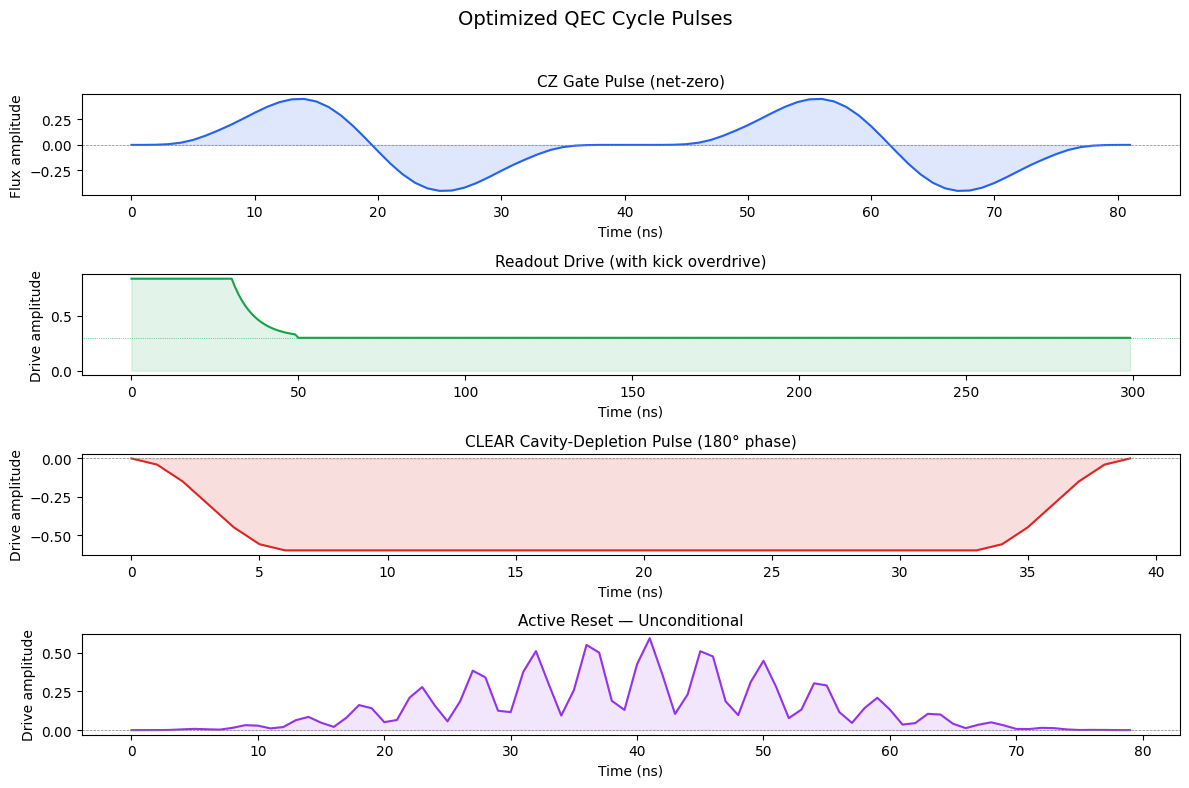

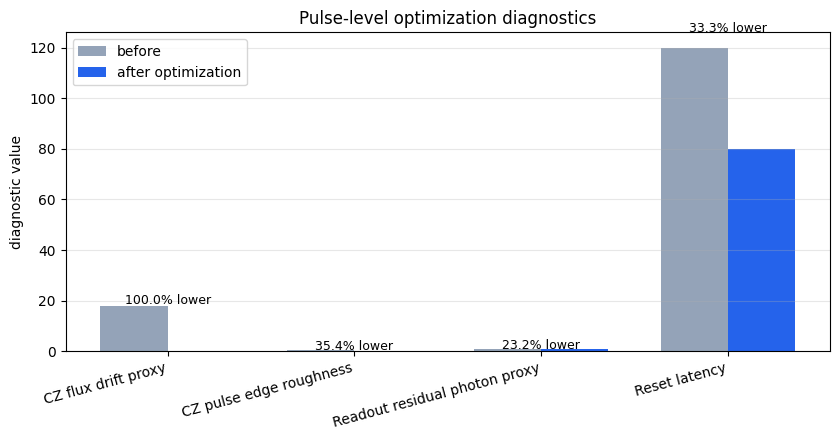

In [143]:
import numpy as np
import matplotlib.pyplot as plt

from get_pulse_config import build_pulse_config_from_calibration

from pulse_control import (
    qec_cycle_schedule,
    pulse_aware_noise_params,
    plot_qec_cycle,
    net_zero_cz_pulse,
    cz_pulse_diagnostics,
    optimized_readout_pulse,
    readout_pulse_diagnostics,
    reset_pulse_diagnostics,
)

# Build pulse settings from calibration data
pulse_cfg, pulse_info = build_pulse_config_from_calibration(CAL)

pulse_schedule = qec_cycle_schedule(pulse_cfg, reset_mode="unconditional")
pulse_noise = pulse_aware_noise_params(
    pulse_cfg,
    t1_ns=pulse_info["t1_ns"],
    t2_ns=pulse_info["t2_ns"],
)

print("Pulse-aware noise parameters:")
for k, v in pulse_noise.items():
    print(f"  {k}: {v:.3e}")

plot_qec_cycle(pulse_schedule, pulse_cfg, save_path=None)

# ---------------------------------------------------------------------
# Simple before/after pulse diagnostics
# ---------------------------------------------------------------------

cfg = pulse_cfg

# Baseline CZ: square flux pulse
square_cz = np.ones(cfg.n_samples(cfg.cz_gate_time_ns)) * cfg.cz_amplitude
square_diag = cz_pulse_diagnostics(square_cz, cfg)

# Optimized CZ: shaped net-zero pulse
optimized_cz = net_zero_cz_pulse(cfg)
optimized_diag = cz_pulse_diagnostics(optimized_cz, cfg)

# Edge roughness: lower means smoother pulse edges
def edge_roughness(waveform):
    padded = np.concatenate([[0.0], waveform, [0.0]])
    return float(np.sum(np.diff(padded) ** 2))

square_roughness = edge_roughness(square_cz)
optimized_roughness = edge_roughness(optimized_cz)

# Readout: compare no CLEAR pulse vs CLEAR pulse
readout, clear = optimized_readout_pulse(cfg)
no_clear_diag = readout_pulse_diagnostics(readout, np.zeros_like(clear), cfg)
with_clear_diag = readout_pulse_diagnostics(readout, clear, cfg)

# Reset: compare conditional reset vs unconditional active reset
reset_diag = reset_pulse_diagnostics(cfg)

candidate_metrics = [
    {
        "metric": "CZ flux drift proxy",
        "baseline": abs(square_diag["net_flux"]),
        "optimized": abs(optimized_diag["net_flux"]),
        "unit": "flux area",
    },
    {
        "metric": "CZ pulse edge roughness",
        "baseline": square_roughness,
        "optimized": optimized_roughness,
        "unit": "roughness",
    },
    {
        "metric": "Readout residual photon proxy",
        "baseline": no_clear_diag["residual_photon_frac"],
        "optimized": with_clear_diag["residual_photon_frac"],
        "unit": "fraction",
    },
    {
        "metric": "Reset latency",
        "baseline": reset_diag["conditional_latency_ns"],
        "optimized": reset_diag["unconditional_latency_ns"],
        "unit": "ns",
    },
]

improvements = [
    m for m in candidate_metrics
    if np.isfinite(m["baseline"])
    and np.isfinite(m["optimized"])
    and m["optimized"] < m["baseline"]
]

print("\nPulse-level optimization improvements")
print("=" * 60)

for m in improvements:
    reduction = 100 * (m["baseline"] - m["optimized"]) / m["baseline"]
    print(f"\n{m['metric']}")
    print(f"  before: {m['baseline']:.4g} {m['unit']}")
    print(f"  after:  {m['optimized']:.4g} {m['unit']}")
    print(f"  improvement: {reduction:.1f}% lower")

# Plot improvements
labels = [m["metric"] for m in improvements]
before = np.array([m["baseline"] for m in improvements])
after = np.array([m["optimized"] for m in improvements])

x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(x - width / 2, before, width, label="before", color="#94a3b8")
ax.bar(x + width / 2, after, width, label="after optimization", color="#2563eb")

for i, m in enumerate(improvements):
    reduction = 100 * (m["baseline"] - m["optimized"]) / m["baseline"]
    ax.text(
        i,
        max(m["baseline"], m["optimized"]) * 1.05,
        f"{reduction:.1f}% lower",
        ha="center",
        fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("diagnostic value")
ax.set_title("Pulse-level optimization diagnostics")
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()